# Mapping mouse Mixl KO to atlas

Atlas is big enough to crash the notebook so try out different partitions?

### Load packages

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(Seurat)
    library(M3C)
    library(batchelor)
})

In [1]:
library(BiocNeighbors)

### I/O

In [2]:
# chimaera
mixl_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/mlnt/3_QC/raw_counts.rds"
mixl_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/2_calledCells/genes.tsv"
mixl_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/mlnt/5_doubletDetection/meta.tab" # contains QC performed by Mlnt

# atlas
atlas_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/raw_counts.mtx"
atlas_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/genes.tsv"
atlas_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/meta.tab"

# out folder
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/"
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"

### Load data

In [3]:
# load mixl data
mixl_counts = readRDS(mixl_data_in)
mixl_genes = read.table(mixl_genes_in, stringsAsFactors = F)
mixl_meta = read.table(mixl_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mixl_meta$cell <- paste0('chim_', mixl_meta$cell)

# annotate mixl counts
rownames(mixl_counts) = mixl_genes[,1] #ensembl
colnames(mixl_counts) = mixl_meta$cell

# load atlas data
atlas_counts = readMM(atlas_data_in) # readMM for .mtx input 
atlas_genes = read.table(atlas_genes_in, stringsAsFactors = F)
atlas_meta = read.table(atlas_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

# annotate atlas counts
rownames(atlas_counts) = atlas_genes[,1] #ensembl
colnames(atlas_counts) = atlas_meta$cell

#### Merge chimaera and atlas data

In [4]:
#### giving both count matrices the same genes in order to merge #######
# mixl genes
mixl_genes2 <- mixl_genes
mixl_genes2$mixl <- 1

# atlas genes
atlas_genes2 <- atlas_genes
atlas_genes2$atlas <- 1

# all genes
all_genes <- merge(mixl_genes2, atlas_genes2, by='V1', all=TRUE)

# mixl only genes
mixl_only <- all_genes[is.na(all_genes$atlas),]$V1
paste0('add to atlas: ', length(mixl_only))
# atlas only genes
atlas_only <- all_genes[is.na(all_genes$mixl),]$V1
paste0('add to mixl: ', length(atlas_only))

[1] "add to atlas: 1765"

[1] "add to mixl: 164"

In [10]:
atlas_genes2

V1,V2,atlas
<chr>,<chr>,<dbl>
ENSMUSG00000051951,Xkr4,1
ENSMUSG00000089699,Gm1992,1
ENSMUSG00000102343,Gm37381,1
ENSMUSG00000025900,Rp1,1
ENSMUSG00000025902,Sox17,1
ENSMUSG00000104328,Gm37323,1
ENSMUSG00000033845,Mrpl15,1
ENSMUSG00000025903,Lypla1,1
ENSMUSG00000104217,Gm37988,1


In [8]:
mixl_genes2

V1,mixl
<chr>,<dbl>
ENSMUSG00000051951,1
ENSMUSG00000089699,1
ENSMUSG00000102343,1
ENSMUSG00000025900,1
ENSMUSG00000025902,1
ENSMUSG00000104328,1
ENSMUSG00000033845,1
ENSMUSG00000025903,1
ENSMUSG00000104217,1


In [11]:
all_genes

V1,mixl,V2,atlas
<chr>,<dbl>,<chr>,<dbl>
ENSMUSG00000000001,1,Gnai3,1
ENSMUSG00000000003,1,Pbsn,1
ENSMUSG00000000028,1,Cdc45,1
ENSMUSG00000000031,1,H19,1
ENSMUSG00000000037,1,Scml2,1
ENSMUSG00000000049,1,Apoh,1
ENSMUSG00000000056,1,Narf,1
ENSMUSG00000000058,1,Cav2,1
ENSMUSG00000000078,1,Klf6,1


In [9]:
all_genes[is.na(all_genes$atlas),]$V1

[1] "ENSMUSG00000041885" "ENSMUSG00000044730" "ENSMUSG00000049229"
   [4] "ENSMUSG00000049235" "ENSMUSG00000054391" "ENSMUSG00000056579"
   [7] "ENSMUSG00000058159" "ENSMUSG00000059460" "ENSMUSG00000060029"
  [10] "ENSMUSG00000060311" "ENSMUSG00000060377" "ENSMUSG00000068463"
  [13] "ENSMUSG00000068776" "ENSMUSG00000069996" "ENSMUSG00000071753"
  [16] "ENSMUSG00000072477" "ENSMUSG00000073028" "ENSMUSG00000074813"
  [19] "ENSMUSG00000075027" "ENSMUSG00000075029" "ENSMUSG00000075070"
  [22] "ENSMUSG00000075128" "ENSMUSG00000076461" "ENSMUSG00000076462"
  [25] "ENSMUSG00000076463" "ENSMUSG00000076465" "ENSMUSG00000076467"
  [28] "ENSMUSG00000076469" "ENSMUSG00000076470" "ENSMUSG00000076471"
  [31] "ENSMUSG00000076472" "ENSMUSG00000076473" "ENSMUSG00000076474"
  [34] "ENSMUSG00000076475" "ENSMUSG00000076476" "ENSMUSG00000076477"
  [37] "ENSMUSG00000076478" "ENSMUSG00000076479" "ENSMUSG00000076480"
  [40] "ENSMUSG00000076481" "ENSMUSG00000076483" "ENSMUSG00000076484"
  [43] "ENSMUSG00000076485" "ENSMUSG00000076486" "ENSMUSG00000076487"
  [46] "ENSMUSG00000076488" "ENSMUSG00000076489" "ENSMUSG00000076490"
  [49] "ENSMUSG00000076492" "ENSMUSG00000076493" "ENSMUSG00000076494"
  [52] "ENSMUSG00000076495" "ENSMUSG00000076496" "ENSMUSG00000076497"
  [55] "ENSMUSG00000076498" "ENSMUSG00000076499" "ENSMUSG00000076500"
  [58] "ENSMUSG00000076501" "ENSMUSG00000076505" "ENSMUSG00000076508"
  [61] "ENSMUSG00000076512" "ENSMUSG00000076514" "ENSMUSG00000076518"
  [64] "ENSMUSG00000076522" "ENSMUSG00000076523" "ENSMUSG00000076525"
  [67] "ENSMUSG00000076526" "ENSMUSG00000076530" "ENSMUSG00000076531"
  [70] "ENSMUSG00000076532" "ENSMUSG00000076533" "ENSMUSG00000076534"
  [73] "ENSMUSG00000076535" "ENSMUSG00000076536" "ENSMUSG00000076538"
  [76] "ENSMUSG00000076539" "ENSMUSG00000076540" "ENSMUSG00000076541"
  [79] "ENSMUSG00000076543" "ENSMUSG00000076545" "ENSMUSG00000076547"
  [82] "ENSMUSG00000076548" "ENSMUSG00000076549" "ENSMUSG00000076550"
  [85] "ENSMUSG00000076552" "ENSMUSG00000076555" "ENSMUSG00000076556"
  [88] "ENSMUSG00000076557" "ENSMUSG00000076562" "ENSMUSG00000076563"
  [91] "ENSMUSG00000076564" "ENSMUSG00000076569" "ENSMUSG00000076570"
  [94] "ENSMUSG00000076571" "ENSMUSG00000076572" "ENSMUSG00000076573"
  [97] "ENSMUSG00000076575" "ENSMUSG00000076576" "ENSMUSG00000076577"
 [100] "ENSMUSG00000076578" "ENSMUSG00000076580" "ENSMUSG00000076581"
 [103] "ENSMUSG00000076583" "ENSMUSG00000076586" "ENSMUSG00000076587"
 [106] "ENSMUSG00000076589" "ENSMUSG00000076591" "ENSMUSG00000076594"
 [109] "ENSMUSG00000076596" "ENSMUSG00000076598" "ENSMUSG00000076604"
 [112] "ENSMUSG00000076605" "ENSMUSG00000076606" "ENSMUSG00000076607"
 [115] "ENSMUSG00000076608" "ENSMUSG00000076609" "ENSMUSG00000076612"
 [118] "ENSMUSG00000076613" "ENSMUSG00000076614" "ENSMUSG00000076615"
 [121] "ENSMUSG00000076617" "ENSMUSG00000076618" "ENSMUSG00000076619"
 [124] "ENSMUSG00000076620" "ENSMUSG00000076621" "ENSMUSG00000076630"
 [127] "ENSMUSG00000076632" "ENSMUSG00000076633" "ENSMUSG00000076646"
 [130] "ENSMUSG00000076652" "ENSMUSG00000076653" "ENSMUSG00000076655"
 [133] "ENSMUSG00000076661" "ENSMUSG00000076665" "ENSMUSG00000076666"
 [136] "ENSMUSG00000076668" "ENSMUSG00000076670" "ENSMUSG00000076671"
 [139] "ENSMUSG00000076672" "ENSMUSG00000076674" "ENSMUSG00000076676"
 [142] "ENSMUSG00000076677" "ENSMUSG00000076680" "ENSMUSG00000076688"
 [145] "ENSMUSG00000076695" "ENSMUSG00000076709" "ENSMUSG00000076710"
 [148] "ENSMUSG00000076731" "ENSMUSG00000076733" "ENSMUSG00000076744"
 [151] "ENSMUSG00000076745" "ENSMUSG00000076746" "ENSMUSG00000076747"
 [154] "ENSMUSG00000076749" "ENSMUSG00000076750" "ENSMUSG00000076752"
 [157] "ENSMUSG00000076754" "ENSMUSG00000076755" "ENSMUSG00000076757"
 [160] "ENSMUSG00000076758" "ENSMUSG00000076759" "ENSMUSG00000076760"
 [163] "ENSMUSG00000076761" "ENSMUSG00000076762" "ENSMUSG00000076764"
 [166] "ENSMUSG00000076770" "ENSMUSG00000076778" "ENSMUSG00000076795"
 [169] "ENSMUSG00000076796" "ENSMUSG00000076800" "ENSMUSG00000076802"
 [172] "ENSMU

In [5]:
# ensure that both count matrices have the same genes
add_mixl <- as.data.frame(matrix(0, ncol = 43825, nrow = 164)) # more elegant if nrow=length(atlas_only) & ncol=nrow(mixl_counts)?
rownames(add_mixl) <- atlas_only
colnames(add_mixl) <- colnames(mixl_counts)
add_atlas <- matrix(0, ncol = 139331, nrow = 1765) # ncol = amount of cells, nrow = genes to add
rownames(add_atlas) <- mixl_only
colnames(add_atlas) <- colnames(atlas_counts)

In [13]:
# Add genes to atlas count matrix
atlas_counts <- rbind(atlas_counts, as(as.matrix(add_atlas), "sparseMatrix"))

In [14]:
# Add genes to mixl count matrix
mixl_counts <- rbind(mixl_counts, as(as.matrix(add_mixl), "sparseMatrix"))

In [15]:
# order gene names
atlas_counts <- atlas_counts[ order(row.names(atlas_counts)), ]

In [16]:
# order gene names
mixl_counts <- mixl_counts[ order(row.names(mixl_counts)), ]

In [1]:
mixl_counts

ERROR: Error in eval(expr, envir, enclos): object 'mixl_counts' not found


In [17]:
dim(mixl_counts)
dim(atlas_counts)

[1] 31217 43825

[1]  31217 139331

In [18]:
# create big count file
big_count <- cbind(atlas_counts, mixl_counts, deparse.level=1)

# save big_sce
saveRDS(big_count, file = paste0(out_folder,"big_count.rds"))

In [19]:
# create SCE object from big_count
big_sce <- SingleCellExperiment(assays = list("counts" = big_count))
saveRDS(big_sce, file = paste0(out_folder,"big_sce.rds"))

In [4]:
###### Creating separate SCE's for atlas and mixl == NOT NEEDED!! ####### 
# create mixl SCE object
mixl_sce = SingleCellExperiment(assays = list("counts" = mixl_counts))

# Extract cells that pass all QC 
mixl_keep <- mixl_meta %>% filter(stripped == FALSE & doublet == FALSE) %>% .$cell
mixl_sce <- mixl_sce[, mixl_keep]

# create atlas SCE object
atlas_sce = SingleCellExperiment(assays = list("counts" = atlas_counts))

## save seperate SCE objects + new metadata
# mixl
saveRDS(mixl_sce, file = paste0(out_folder,"mixl_sce.rds"))
mixl_meta <- mixl_meta %>% filter(stripped == FALSE & doublet == FALSE)
write.table(mixl_meta, file = paste0(out_folder, "mixl_meta.tab"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

# atlas
saveRDS(atlas_sce, file = paste0(out_folder,"atlas_sce.rds"))
write.table(atlas_meta, file = paste0(out_folder, "atlas_meta.tab"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

ERROR: Error in normarg_assays(assays): object 'mixl_counts' not found


In [20]:
mixl_meta = read.table(mixl_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [21]:
head(mixl_meta)

,cell,barcode,sample,stage,batch,stripped,doublet
,<chr>,<chr>,<int>,<dbl>,<int>,<lgl>,<lgl>
1,cell_1,AAACCCAAGCATAGGC,1,8.5,1,FALSE,FALSE
2,cell_2,AAACCCAAGGGACTGT,1,8.5,1,FALSE,FALSE
3,cell_3,AAACCCACAAGCAATA,1,8.5,1,FALSE,FALSE
4,cell_4,AAACCCACATCTTCGC,1,8.5,1,FALSE,FALSE
5,cell_5,AAACCCAGTATCTCTT,1,8.5,1,FALSE,FALSE
6,cell_6,AAACCCAGTCCAATCA,1,8.5,1,FALSE,FALSE


#### Creating metadata

### collection metadata used here is wrong!! this is update in notebook 05_tdTom_check 

In [24]:
#### create big_metadata ####
# import metadata (fresh, in case its messed up by trial code)
mixl_meta = read.table(mixl_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mixl_meta$cell <- paste0('chim_', mixl_meta$cell) # to differentiate chim cells from atlas cells

atlas_meta = read.table(atlas_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

# add string in front of sample to differentiate atlas from chimaera
atlas_meta$sample <- paste0('atlas_',atlas_meta$sample)
mixl_meta$sample <- paste0('mixl_',mixl_meta$sample)

# put both metas in same format
atlas_original <- atlas_meta
atlas_meta <- atlas_meta %>% select('cell', 'barcode', 'sample','stage','sequencing.batch','stripped','doublet')
colnames(mixl_meta) <- c('cell', 'barcode', 'sample','stage','sequencing.batch','stripped','doublet')

mixl_meta$stage <- paste0('E',mixl_meta$stage)

# rbind
big_meta <- rbind(atlas_meta, mixl_meta)

# merge with original atlas_meta
big_meta <- merge(big_meta, atlas_original, by=c('cell', 'barcode', 'sample','stage','sequencing.batch','stripped','doublet'), all=TRUE)

# Add tdTomato information to metadata
collection <- read.csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/chim_collection_meta.csv")
collection$sample <- paste0('mixl_',collection$sample)
collection$stage <- paste0('E',collection$stage)
collection$tdTom <- sapply(strsplit(collection$Sample.Name,"_"), `[`, 3)
collection$tdTom <- str_replace(collection$tdTom, c("tdTomPOS","tdTomNEG"), c('pos', 'neg'))
collection <- collection %>% select(sample, stage, tdTom)

big_meta <- merge(big_meta, collection, by=c('sample', 'stage'), all=TRUE)

# Give metadata same order as big_sce
cells <- colnames(big_sce)
keyDF <- data.frame(key=cells,weight=1:length(cells))
merged <- merge(big_meta,keyDF,by.x='cell',by.y='key',all.x=T,all.y=T)
big_meta <- merged %>% arrange(weight)

# write
write.table(big_meta, file = paste0(out_folder,"big_meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [35]:
#### gene metadata #####
genes <- data.frame(rownames(big_sce))
write.table(genes, file = paste0(out_folder,"big_genes.tab"), row.names = F, col.names = F, quote = F, sep = "\t")

#### Quality filter cells

In [2]:
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_sce <- readRDS(paste0(out_folder, "big_sce.rds"))
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [3]:
library(magrittr)

In [ ]:
# extract cells to keep
keep <- big_meta %>% filter(stripped == FALSE & doublet == FALSE) %>% .$cell
# keep only those cells in big_sce
saveRDS(big_sce, file = paste0(out_folder,"big_sce_before_QC.rds"))
big_sce <- big_sce[, keep]
# save big_sce
saveRDS(big_sce, file = paste0(out_folder,"big_sce.rds"))

In [6]:
# save meta before cleaning
write.table(big_meta, file = paste0(out_folder,"big_meta_before_QC.tab"), row.names = F, col.names = T, quote = F, sep = "\t")
# clean meta
big_meta <- big_meta %>% filter(stripped == FALSE & doublet == FALSE)
# save meta after cleaning
write.table(big_meta, file = paste0(out_folder,"big_meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

ERROR: Error in is.data.frame(x): object 'big_meta' not found


In [4]:
# confirm SCE and metadata still overlap
summary(big_meta$cell == colnames(big_sce))

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tap

   Mode   FALSE    TRUE 
logical  183154       2 

#### Normalize

In [60]:
# calculate sizefactors
clusts = as.numeric(quickCluster(big_sce, method = "igraph", min.size = 100, BPPARAM = mcparam))
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
big_sce = computeSumFactors(big_sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)
write.table(sizeFactors(big_sce), quote = F, col.names = F, row.names = F, file = paste0(out_folder,"sizefactors_big.tab"))

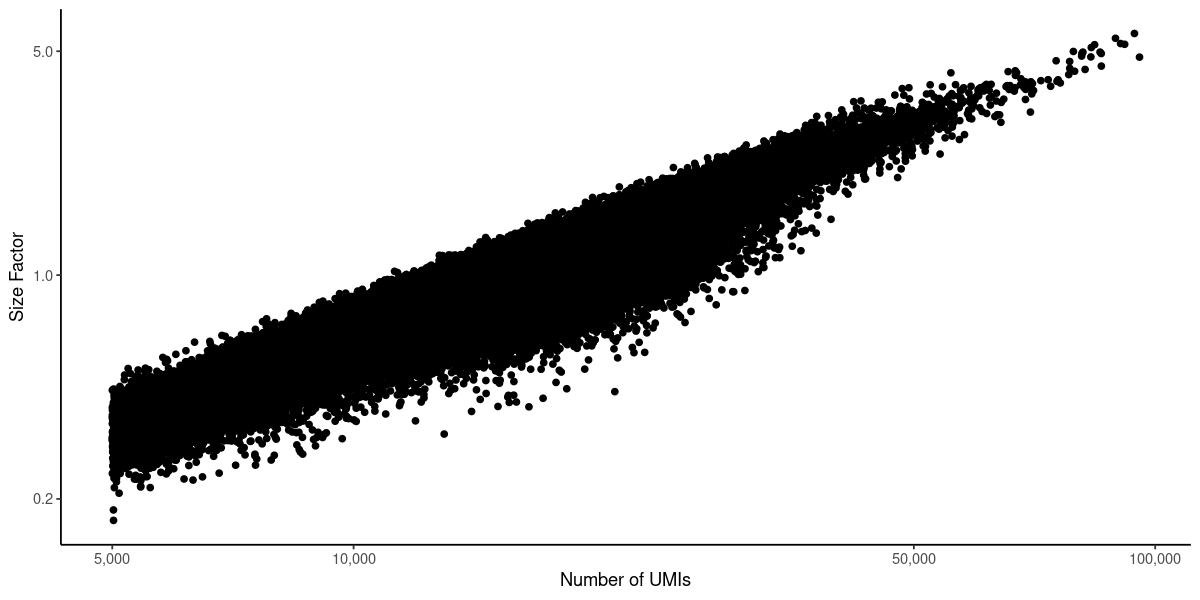

In [61]:
lib.sizes = Matrix::colSums(counts(big_sce))
ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(big_sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") + 
    theme_classic()

In [62]:
# Normalize
sfs = read.table(paste0(out_folder,"sizefactors_big.tab"), stringsAsFactors = F)[,1]
sizeFactors(big_sce) = sfs
big_sce = scater::logNormCounts(big_sce)

In [63]:
# save normalized sce
saveRDS(big_sce, file = paste0(out_folder,"big_sce_norm.rds"))

In [5]:
big_sce_norm <- readRDS(paste0(out_folder, "big_sce_norm.rds"))
str(big_sce_norm)


Formal class 'SingleCellExperiment' [package "SingleCellExperiment"] with 9 slots
  ..@ int_elementMetadata:Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. ..@ rownames       : NULL
  .. .. ..@ nrows          : int 31217
  .. .. ..@ listData       : Named list()
  .. .. ..@ elementType    : chr "ANY"
  .. .. ..@ elementMetadata: NULL
  .. .. ..@ metadata       : list()
  ..@ int_colData        :Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. ..@ rownames       : NULL
  .. .. ..@ nrows          : int 153520
  .. .. ..@ listData       :List of 2
  .. .. .. ..$ reducedDims:Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. .. .. .. ..@ rownames       : NULL
  .. .. .. .. .. ..@ nrows          : int 153520
  .. .. .. .. .. ..@ listData       : Named list()
  .. .. .. .. .. ..@ elementType    : chr "ANY"
  .. .. .. .. .. ..@ elementMetadata: NULL
  .. .. .. .. .. ..@ metadata       : list()
  .. .. .. ..$ altExps    :Formal class 'DFrame' [pac

#### HVGs

In [6]:
big_sce <- readRDS(paste0(out_folder, "big_sce_norm.rds"))

In [64]:
big_sce

class: SingleCellExperiment 
dim: 31217 153520 
metadata(0):
assays(2): counts logcounts
rownames(31217): ENSMUSG00000000001 ENSMUSG00000000003 ...
  ENSMUSG00000116989 ENSMUSG00000116993
rowData names(0):
colnames(153520): atlas_cell_1 atlas_cell_2 ... chim_cell_43824
  chim_cell_43825
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

In [66]:
# ygenes
ygenes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/ygenes.tab"

In [67]:
# load genes
ychr_e = read.table(ygenes_in, stringsAsFactors = F)[,1]
genes_meta = read.table(paste0(out_folder,"big_genes.tab"), stringsAsFactors = F)
rownames(genes_meta) = genes_meta$V1

# filter sex genes (Xist + ygenes)
paste0('genes before filtering: ', length(rownames(big_sce)))
big_sce   <- big_sce[!rownames(big_sce) %in% c('ENSMUSG00000086503', ychr_e),]
paste0('genes after filtering: ', length(rownames(big_sce)))

[1] "genes before filtering: 31217"

[1] "genes after filtering: 30483"

In [69]:
p.val_th = 0.05 # p-value threshold

# determine top HVGs
dec <- modelGeneVar(big_sce)
hvg_p <- getTopHVGs(dec, fdr.threshold = p.val_th)
paste0('number of HVGs based on P value: ', length(hvg_p))
hvg_n <- getTopHVGs(dec, n = 3000)

# save
write.csv(hvg_p, file =  paste0(out_folder,"big_hvgs_p.csv"))
write.csv(hvg_n, file =  paste0(out_folder,"big_hvgs_3000.csv"))

[1] "number of HVGs based on P value: 660"

#### Batch correction

In [70]:
BPPARAM = SerialParam()

# I/O
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_sce <- readRDS(paste0(out_folder, "big_sce_norm.rds"))
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
hvgs = read.csv(paste0(out_folder,"big_hvgs_3000.csv"))$x

In [71]:
#### Cosine normalisation ##### 
# add metadata combining stage & sample
big_meta$comb <- paste0(big_meta$stage, "_", big_meta$sample)

# extract counts for each combination
mat_temp = logcounts(big_sce)
mat = mat_temp[hvgs,]

# seperate count matrices based on combination
comb <- list()
for(i in unique(big_meta$comb)){
    comb[[i]] <- mat[, big_meta$comb == i]
}
paste0('nr of combinations: ', length(comb))

# cosine normalize
comb_cos <- list()
for(i in 1:length(comb)){
    comb_cos[[i]] <- cosineNorm(comb[[i]])
}

[1] "nr of combinations: 42"

In [72]:
######## from here on everything takes a while so may be better to run in Rscript rather than notebook
#### calculate PCs #####
big_pca = multiBatchPCA(comb_cos ,BPPARAM = BPPARAM,d = 50)

In [73]:
saveRDS(big_pca, file=paste0(out_folder, 'uncorrected_PCs_multibatch.rds'))
big_pca <- do.call(rbind, big_pca)
saveRDS(big_pca, file=paste0(out_folder, 'uncorrected_PCs.rds'))

### pay attention from here!!

In [41]:
big_pca <- readRDS(paste0(out_folder, 'uncorrected_PCs.rds'))
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [42]:
# give chimaera different stage value to make batch correction easier
big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1)
big_meta$stage[which(big_meta$origin == "chim")] <- 'E8.5_chim'

In [43]:
#### reducedMNN preparation ##### (run in next cell)
set.seed(42)
# over several iterations 

# order of batch corrections --> input chimaera as seperate timepoint to make looping easier
#### This way chimaera's will still be batch corrected separately from atlas.
order_df = big_meta[!duplicated(big_meta$sample), c("stage", "sample")]
order_df$ncells = sapply(order_df$sample, function(x) sum(big_meta$sample == x))
order_df$stage = factor(order_df$stage,
                          levels = rev(c("E8.5", 
                                         "E8.25", 
                                         "E8.0", 
                                         "E7.75", 
                                         "E7.5", 
                                         "E7.25", 
                                         "mixed_gastrulation", 
                                         "E7.0", 
                                         "E6.75", 
                                         "E6.5",
                                         "E8.5_chim"))) # Chimaera last!
order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage = as.character(order_df$stage)
order_df$comb <- paste0(order_df$stage, "_", order_df$sample)

# defenitions for creating nested lists                         
timepoints = big_meta$stage
samples = big_meta$sample
timepoint_order = order_df$stage
sample_order = order_df$sample

#create nested list
  pc_list = lapply(unique(timepoints), function(tp){
    sub_pc = big_pca[timepoints == tp, , drop = FALSE]
    sub_samp = samples[timepoints == tp]
    list = lapply(unique(sub_samp), function(samp){
     sub_pc[sub_samp == samp, , drop = FALSE]
    })
    names(list) = unique(sub_samp)
    return(list)
  })

  names(pc_list) = unique(timepoints)

  #arrange to match timepoint order
  pc_list = pc_list[order(match(names(pc_list), timepoint_order))]
  pc_list = lapply(pc_list, function(x){
    x[order(match(names(x), sample_order))]
  })

# create if statement for following numbers in next cell:
print('create if statement for following values: ')
    for(i in 1:length(pc_list)){
    print(length(pc_list[[i]]))
}

[1] "create if statement for following values: "
[1] 4
[1] 3
[1] 4
[1] 4
[1] 6
[1] 3
[1] 2
[1] 6
[1] 1
[1] 3
[1] 6


In [46]:
# reducedMNN within timepoints
# reducedMNN is too stupid to understand looping over list so each list element has to be inputted as seperate object
# done with if statement so you don't have to write a seperate line for each nested list
corrected_pcs <- list()
for(i in 1:length(pc_list)){
    if(length(pc_list[[i]]) == 1){
        corrected_pcs[[i]] <- unlist(pc_list[[i]][[1]])
    }
    if(length(pc_list[[i]]) == 2){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 3){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 4){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 5){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 6){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]], pc_list[[i]][[6]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 10){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]], pc_list[[i]][[6]],pc_list[[i]][[7]], pc_list[[i]][[8]], pc_list[[i]][[9]],pc_list[[i]][[10]],BPPARAM = SerialParam())$corrected
    }
}

saveRDS(corrected_pcs, file=paste0(out_folder, 'corrected_PCs_time_multibatch.rds'))
temp = do.call(rbind, corrected_pcs)
write.csv(temp, paste0(out_folder, 'corrected_pc_time.csv'))

In [48]:
nrow(temp) == nrow(big_meta) # sanity check if we still have the same amount of cells

[1] TRUE

In [55]:
# correct across timepoints of atlas only (corrected_pcs 1 - 10)
correct_atlas = reducedMNN(corrected_pcs[[1]], corrected_pcs[[2]], corrected_pcs[[3]],corrected_pcs[[4]], corrected_pcs[[5]], corrected_pcs[[6]],corrected_pcs[[7]], corrected_pcs[[8]], corrected_pcs[[9]],corrected_pcs[[10]], BPPARAM = SerialParam())$corrected

In [56]:
# correct atlas + chimaera
correct_complete = reducedMNN(correct_atlas, corrected_pcs[[11]], BPPARAM = SerialParam())$corrected
# save temp corrected PCs
write.csv(correct_complete, paste0(out_folder, 'corrected_pc_complete_unordered.csv')) 

In [57]:
correct_complete_bu <- correct_complete

In [58]:
correct_complete <- correct_complete_bu

In [59]:
# order pcs according to metadata
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
cells <- big_meta$cell
keyDF <- data.frame(key=cells,weight=1:length(cells))
correct_complete <- as.data.frame(correct_complete)
correct_complete$cell <- rownames(correct_complete)
merged <- merge(correct_complete,keyDF,by.x='cell',by.y='key',all.x=T,all.y=T)
correct_complete <- merged %>% arrange(weight)
correct_complete$weight <- NULL
rownames(correct_complete) <- correct_complete$cell
correct_complete$cell <- NULL

In [60]:
# save final corrected PCs
write.csv(correct_complete, paste0(out_folder, 'corrected_pc_complete.csv')) 

### UMAP visualisation --> eventually done in SCANPY instead

In [16]:
# Load in data
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
pca_before = as.data.frame(readRDS(paste0(out_folder, 'uncorrected_PCs.rds')))
pca_before$cell <- rownames(pca_before)
pca_after = as.data.frame(read.csv(paste0(out_folder, 'corrected_pc_complete.csv'), header=T, row.names=1,sep=","))
pca_after$cell <- rownames(pca_after)

In [17]:
# add metadata to PCs
pca_before <- merge(pca_before, big_meta, by='cell')
rownames(pca_before) <- pca_before$cell
pca_after <- merge(pca_after, big_meta, by='cell')
rownames(pca_after) <- pca_after$cell

In [ ]:
# calculate umap's on whole object and chimeara seperately
### chimaera only
# before correction
pca_before$origin <- sapply(strsplit(pca_before$cell,"_"), `[`, 1)
chim_before <- pca_before %>% filter(origin=='chim') %>% select(2:51) # Use all 51 PCs for UMAP
chim_before_umap = umap(t(chim_before))$data
chim_before_umap <- as.data.frame(chim_before_umap)
colnames(chim_before_umap) <- c('umap1','umap2')
chim_before_umap$cell <- rownames(chim_before)
chim_before_umap <- merge(chim_before_umap, big_meta, by='cell')
# write
write.csv(chim_before_umap, paste0(out_folder, 'umap_before_correction_chim.csv')) 
print('finished first umap')


# after correction
pca_after$origin <- sapply(strsplit(pca_after$cell,"_"), `[`, 1)
chim_after <- pca_after %>% filter(origin=='chim') %>% select(2:51) 
chim_after_umap = umap(t(chim_after))$data
chim_after_umap<- as.data.frame(chim_after_umap)
colnames(chim_after_umap) <- c('umap1','umap2')
chim_after_umap$cell <- rownames(chim_after)
chim_after_umap <- merge(chim_after_umap, big_meta, by='cell')
# write
write.csv(chim_after_umap, paste0(out_folder, 'umap_after_correction_chim.csv')) 
print('finished second umap')

### whole object
# before correction
pca_before$origin <- sapply(strsplit(pca_before$cell,"_"), `[`, 1)
pca_before <- pca_before %>% select(2:51)
pca_before_umap = umap(t(pca_before))$data
pca_before_umap <- as.data.frame(pca_before_umap)
colnames(pca_before_umap) <- c('umap1','umap2')
pca_before_umap$cell <- rownames(pca_before)
pca_before_umap <- merge(pca_before_umap, big_meta, by='cell')
# write
write.csv(pca_before_umap, paste0(out_folder, 'umap_before_correction.csv')) 
print('finished third umap')

# after correction
pca_after$origin <- sapply(strsplit(pca_after$cell,"_"), `[`, 1)
pca_after <- pca_after %>% select(2:51)
pca_after_umap = umap(t(pca_after))$data
pca_after_umap <- as.data.frame(pca_after_umap)
colnames(pca_after_umap) <- c('umap1','umap2')
pca_after_umap$cell <- rownames(pca_after)
pca_after_umap <- merge(pca_after_umap, big_meta, by='cell')
# write
write.csv(pca_after_umap, paste0(out_folder, 'umap_after_correction.csv')) 
print('finished fourth umap')

In [2]:
# load in data
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
chim_before_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_before_correction_chim.csv'), header=T, row.names=1,sep=","))
chim_after_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction_chim.csv'), header=T, row.names=1,sep=","))
pca_before_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_before_correction.csv'), header=T, row.names=1,sep=","))
pca_after_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=","))

In [3]:
# plot umaps

# colors
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")

# chimaera
options(repr.plot.width = 10, repr.plot.height = 5)
p1 <- ggplot(chim_before_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('chimaera only, before correction, color = samples')
p2 <- ggplot(chim_before_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('chimaera only, before correction, color =  tomato')

p3 <- ggplot(chim_after_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('chimaera only, after correction, color = samples')
p4 <- ggplot(chim_after_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('chimaera only, after correction, color = tomato')

# whole object
p5 <- ggplot(pca_before_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('whole object before correction, color = sample')
p6 <- ggplot(pca_after_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('whole object after correction, color = sample')

p7 <- ggplot(pca_before_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('whole object before correction, color = tomato')
p8 <- ggplot(pca_after_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('whole object after correction, color = tomato')

p9 <- ggplot(pca_before_umap, aes(umap1, umap2, color=stage)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = stage_colours, labels = stage_labels, name = "stage") +
    ggtitle('whole object before correction, color = timepoint')
p10 <- ggplot(pca_after_umap, aes(umap1, umap2, color=stage)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = stage_colours, labels = stage_labels, name = "stage") +
    ggtitle('whole object after correction, color = timepoint')

atlas_before_umap <- pca_before_umap %>% filter(!is.na(celltype))
p11 <- ggplot(atlas_before_umap, aes(umap1, umap2, color=celltype)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    ggtitle('atlas only before correction, color = celltype')
atlas_after_umap <- pca_after_umap %>% filter(!is.na(celltype))
p12 <- ggplot(atlas_after_umap, aes(umap1, umap2, color=celltype)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    ggtitle('atlas only after correction, color = celltype')

pca_before_85 <- pca_before_umap %>% filter(stage == 'E8.5')
p13 <- ggplot(pca_before_85, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('E8.5 before correction, color = tomato')
pca_after_85 <- pca_after_umap %>% filter(stage == 'E8.5')
p14 <- ggplot(pca_after_85, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.4) +
    theme_classic() +
    ggtitle('E8.5 after correction, color = tomato')

pca_before_umap$origin <- sapply(strsplit(pca_before_umap$cell,"_"), `[`, 1)
p15 <- ggplot(pca_before_umap, aes(umap1, umap2, color= origin)) +
    geom_point(alpha=0.2, size = 0.4) +
    theme_classic() +
    ggtitle('whole object after correction, color = experiment')
pca_after_umap$origin <- sapply(strsplit(pca_after_umap$cell,"_"), `[`, 1)
p16 <- ggplot(pca_after_umap, aes(umap1, umap2, color= origin)) +
    geom_point(alpha=0.2, size = 0.4) +
    theme_classic() +
    ggtitle('whole object after correction, color = experiment')

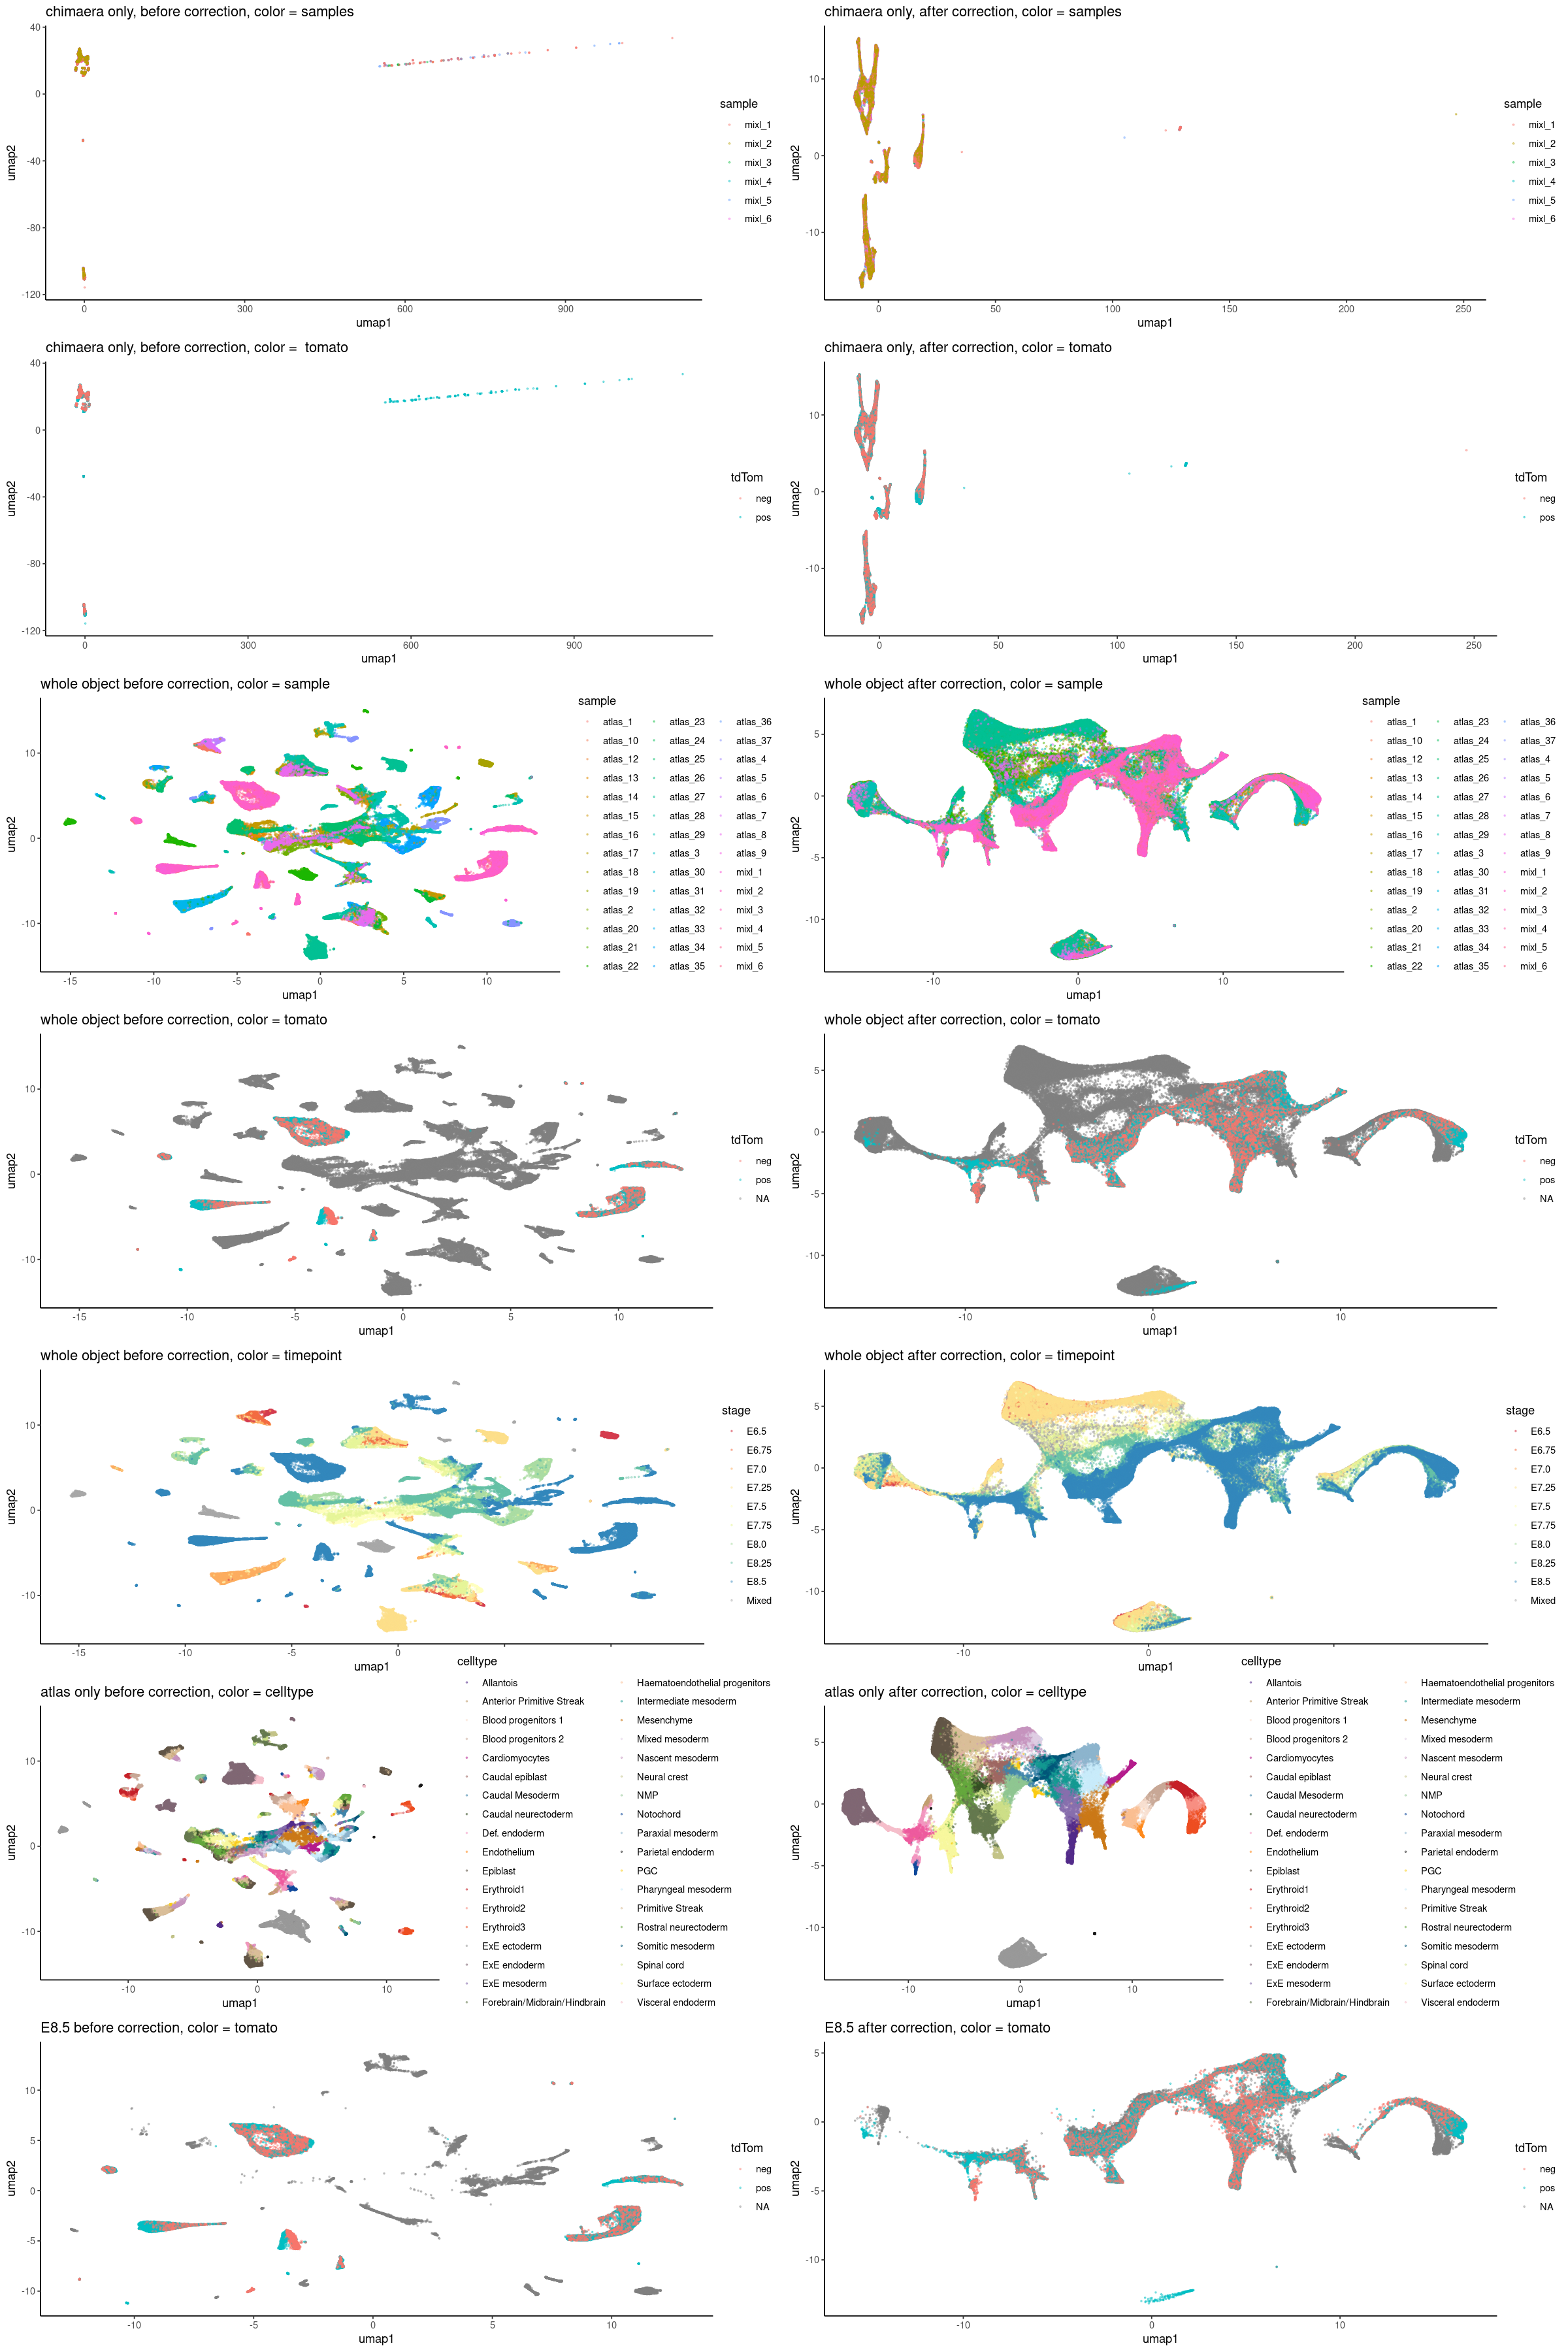

In [5]:
options(repr.plot.width = 20, repr.plot.height = 30)
    grid.arrange(p1, p3, p2, p4, p5, p6, p7, p8, p9, p10, p11, p12, p13, p14, nrow =7)

In [16]:
pdf(paste0(plot_folder, "umap_batch_correction_comparisons_chimaera.pdf"), useDingbats = FALSE, height=10, width=10)
    grid.arrange(p1, p3, p2, p4, nrow =2)
dev.off()

png 
  2

In [12]:
# plot to png instead of pdf to stop laptop from burning
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_batch_correction_comparisons.png"), height=5000, width=3500)
    grid.arrange(p1, p3, p2, p4, p5, p6, p7, p8, p9, p10, p11, p12, p13, p14, nrow =7)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_chimaera.png"), height=1000, width=1000)
    grid.arrange(p1, p3, p2, p4, nrow =2)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_sample.png"), height=1000, width=2500)
    grid.arrange(p5, p6, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_tomato.png"), height=1000, width=2500)
    grid.arrange(p7, p8, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_timepoint.png"), height=1000, width=2500)
    grid.arrange(p9, p10, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_celltype.png"), height=1000, width=2500)
    grid.arrange(p11, p12, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_E85.png"), height=1000, width=2500)
    grid.arrange(p13, p14, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_corrected_plots.png"), height=2000, width=3500)
    grid.arrange(p6, p8, p12, p10, nrow =2)
dev.off()

png(paste0(plot_folder, "umap_batch_corrected_origin.png"), height=1000, width=2500)
    grid.arrange(p15, p16, nrow =1)
dev.off()

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

In [176]:
pca_after_85 <- pca_after_umap %>% filter(stage == 'E8.5')
pca_after_85 <- pca_after_85 %>% filter(umap2 >= -10)
p14 <- ggplot(pca_after_85, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.2, size = 1, color='grey') +
    geom_point(data=pca_after_85, aes(umap1, umap2, color=tdTom),alpha=0.2, size = 1) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) +
    ggtitle('E8.5 only, color = tomato')

Warning message:
“Removed 16907 rows containing missing values (geom_point).”


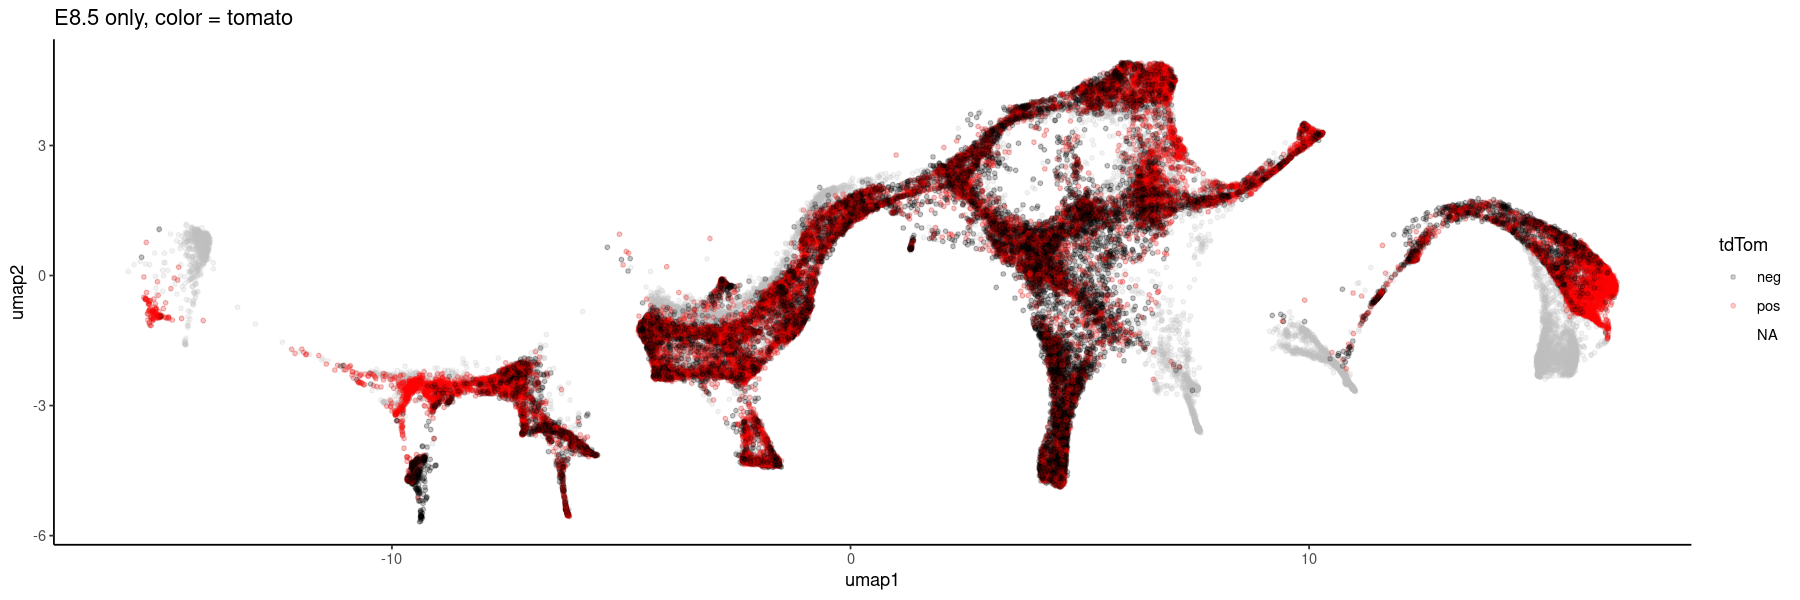

In [178]:
options(repr.plot.width = 15, repr.plot.height = 5)
p14

In [180]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_85_tomato.png"), height=1000, width=1300)
    grid.arrange(p14)
dev.off()


Warning message:
“Removed 16907 rows containing missing values (geom_point).”


png 
  2

#### Map

In [80]:
# Load in data
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
pca_after = as.data.frame(read.csv(paste0(out_folder, 'corrected_pc_complete.csv'), header=T, row.names=1,sep=","))
pca_after$cell <- rownames(pca_after)

In [81]:
# label origin in metdata
big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1) 

In [82]:
# split atlas and chimaera
atlas_cells = big_meta %>% filter(origin=='atlas') %>% .$cell
correct_atlas = pca_after %>% filter(cell %in% atlas_cells)
atlas_meta = big_meta %>% filter(origin=='atlas')
correct_map = pca_after %>% filter(!cell %in% atlas_cells) %>% select(1:50) # keep only PC columns
map_meta = big_meta %>% filter(origin!='atlas') 

In [83]:
# Downsample atlas to 10k cells per timepoint
keep = lapply(unique(atlas_meta$stage), function(x){
  if(x == "mixed_gastrulation"){
    return(atlas_meta[atlas_meta$stage == x,]$cell)
  } else if(sum(atlas_meta$stage == x) < 10000) {
    return(atlas_meta[atlas_meta$stage == x,]$cell)
  } else {
    return(atlas_meta[atlas_meta$stage == x,]$cell)
    return(sample(hits, 10000))
  }
})
keep = do.call(c, keep)
keep <- as.list(keep)

atlas_meta = atlas_meta %>% filter(cell %in% keep)
correct_atlas = correct_atlas %>% filter(cell %in% keep) %>% select(1:50)

In [87]:
## Code for mapping:

getmode <- function(v, dist) {
  tab = table(v)
  #if tie, break to shortest distance
  if(sum(tab == max(tab)) > 1){
    tied = names(tab)[tab == max(tab)]
    sub = dist[v %in% tied]
    names(sub) = v[v %in% tied]
    return(names(sub)[which.min(sub)])
  } else {
    return(names(tab)[which.max(tab)])
  }
}

mnnMap = function(atlas_pca, atlas_meta, map_pca, map_meta, k_map = 10){
  require(BiocNeighbors)
  require(scran)
  
  knns = BiocNeighbors::queryKNN(correct_atlas, correct_map, k = k_map, get.index = TRUE, get.distance = FALSE)
  
  #get closest k matching cells
  k.mapped = t(apply(knns$index, 1, function(x) atlas_meta$cell[x]))
  celltypes = t(apply(k.mapped, 1, function(x) atlas_meta$celltype[match(x, atlas_meta$cell)]))
  stages = t(apply(k.mapped, 1, function(x) atlas_meta$stage[match(x, atlas_meta$cell)]))
  celltype.mapped = apply(celltypes, 1, function(x) getmode(x, 1:length(x)))
  stage.mapped = apply(stages, 1, function(x) getmode(x, 1:length(x)))
  
  out = lapply(1:length(celltype.mapped), function(x){
    list(cells.mapped = k.mapped[x,],
         celltype.mapped = celltype.mapped[x],
         stage.mapped = stage.mapped[x])
  })
  
  names(out) = map_meta$cell

  return(out)
  
}

In [ ]:
# Perform mapping:
mapping = mnnMap(correct_atlas, atlas_meta, correct_map, map_meta, k_map = 10)

  cn = substr(names(mapping), 5, nchar(names(mapping))) # remove 
  ct = sapply(mapping, function(x) x$celltype.mapped)
  st = sapply(mapping, function(x) x$stage.mapped)
  closest = sapply(mapping, function(x) x$cells.mapped[1])
  
  out = data.frame(cell = cn, celltype.mapped = ct, stage.mapped = st, closest.cell = closest)
                   
# save mapped celltypes
write.csv(out, paste0(out_folder, 'chimaera_mapped_celltypes.csv')) 

In [25]:
### visualise mapping
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mapping <- read.csv(paste0(out_folder, 'chimaera_mapped_celltypes.csv'), row.names=1)
mapping$cell <- rownames(mapping)

# add cell mapping to metadata
big_meta$stage.mapped = as.character(mapping$stage.mapped[match(big_meta$cell, mapping$cell)])
big_meta$celltype.mapped = as.character(mapping$celltype.mapped[match(big_meta$cell, mapping$cell)])
big_meta$closest.cell = as.character(mapping$closest.cell[match(big_meta$cell, mapping$cell)])

# only plot chimaera cells
meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

In [27]:
### save big meta with mapping
write.table(big_meta, file = paste0(out_folder,"big_meta_mapping.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [3]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

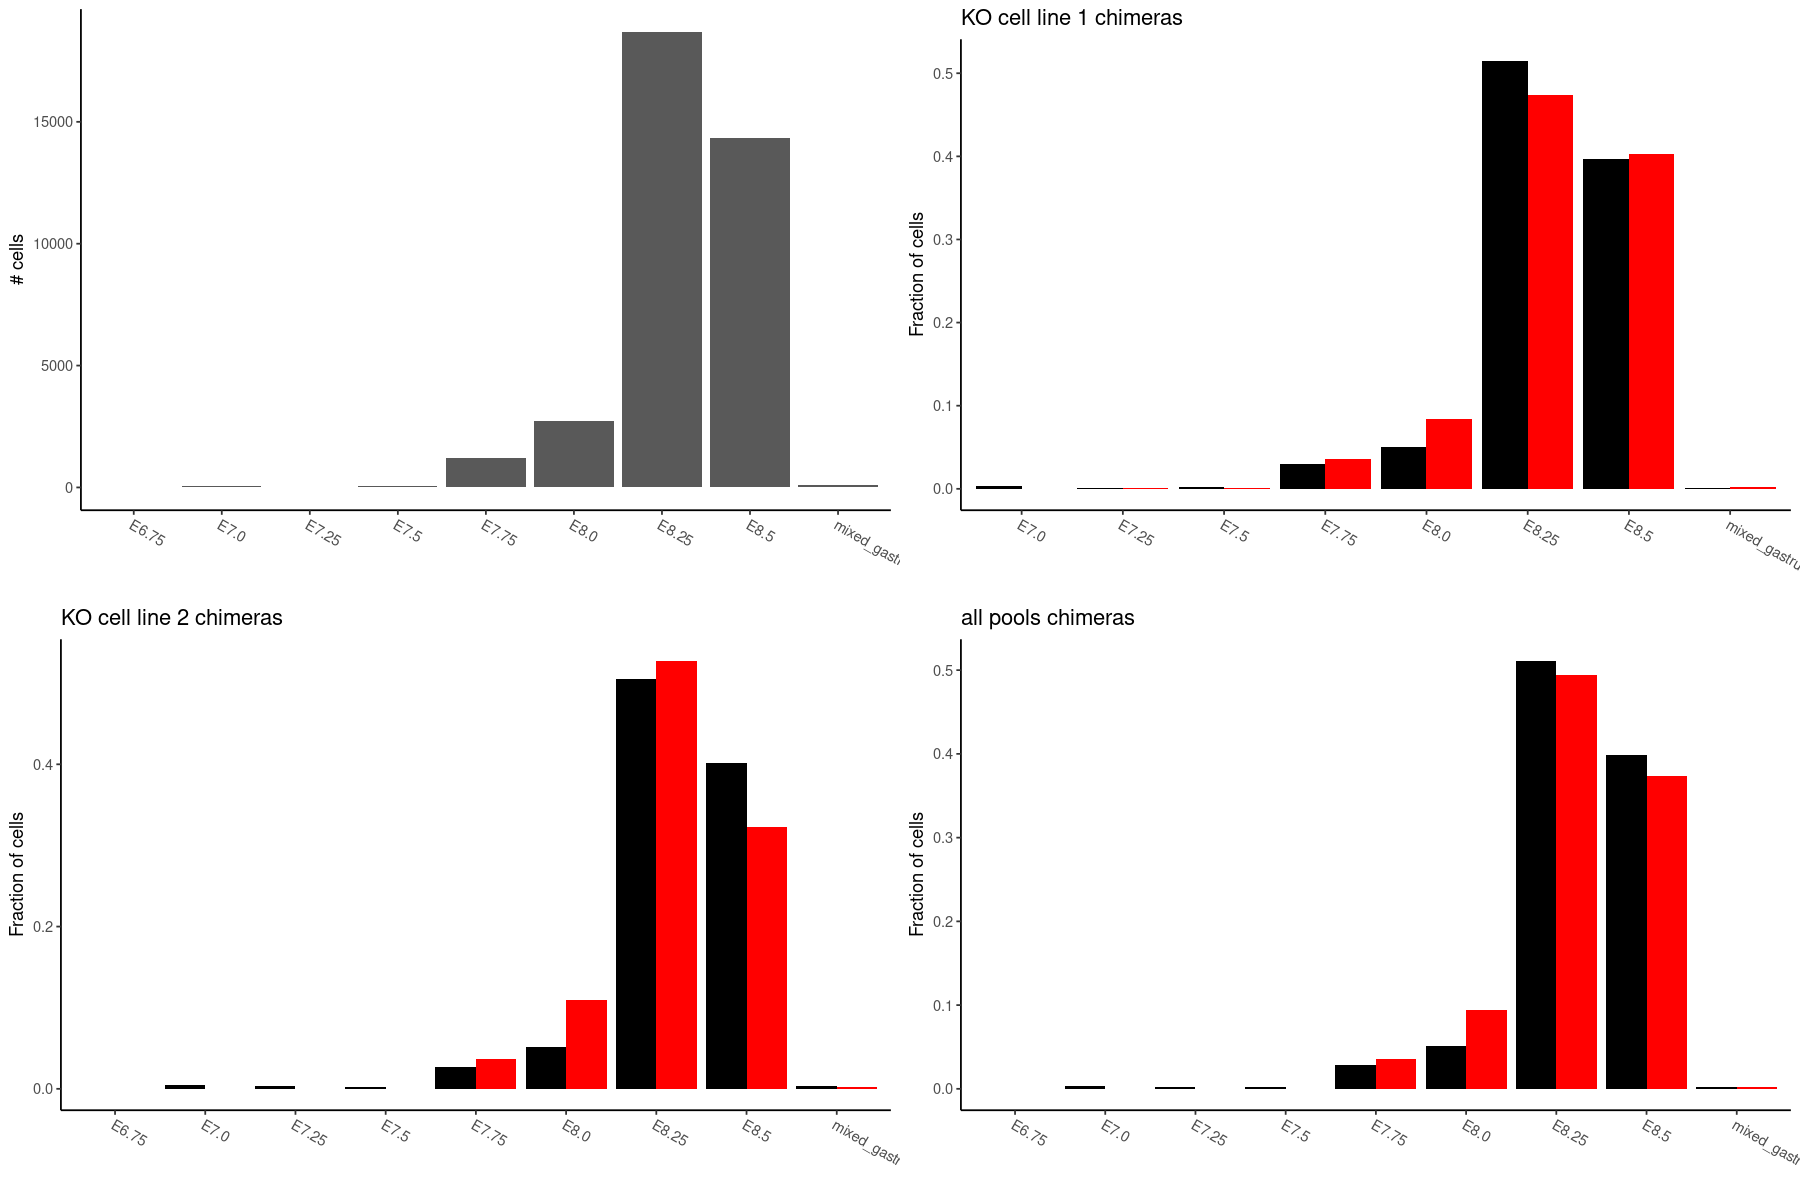

In [7]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4')
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$stage.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas stage", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])
  
  

pdf1 = table(meta$stage.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])


pdf2 = table(meta$stage.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$stage.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])

options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [8]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
pdf(paste0(plot_folder, "chimaera_stage_mapping.pdf"), height=8, width=10)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

png 
  2

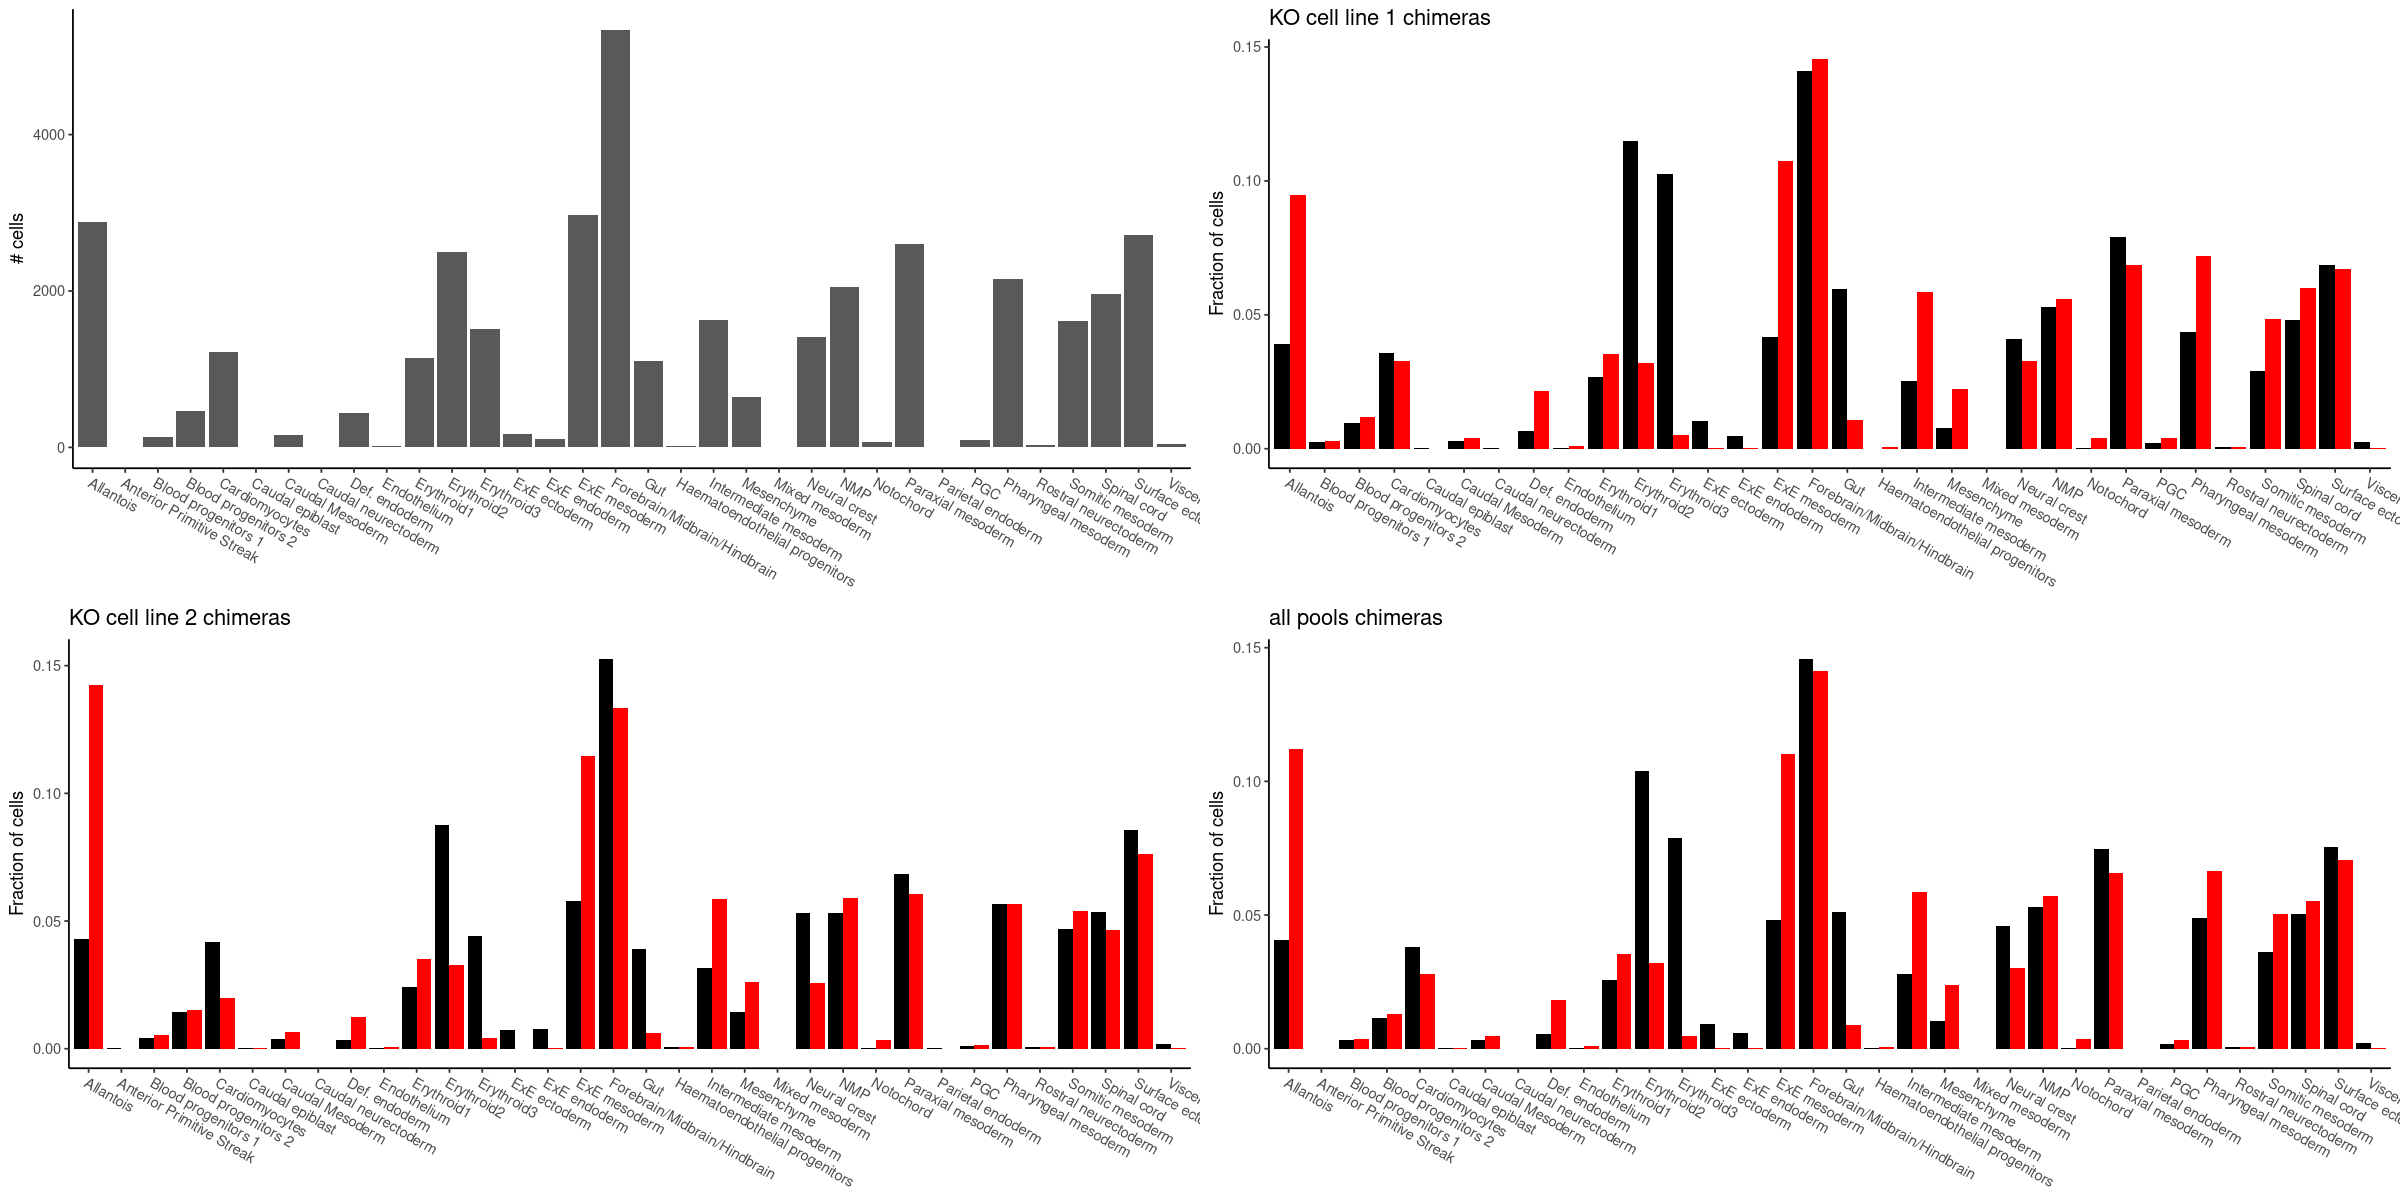

In [9]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$celltype.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas celltype", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])
  
  

pdf1 = table(meta$celltype.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])


pdf2 = table(meta$celltype.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$celltype.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [10]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
pdf(paste0(plot_folder, "chimaera_celltype_mapping.pdf"), height=8, width=20)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

png 
  2

Warning message:
“Transformation introduced infinite values in continuous x-axis”
Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Transformation introduced infinite values in continuous x-axis”
Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Transformation introduced infinite values in continuous x-axis”
Warning message:
“Transformation introduced infinite values in continuous x-axis”
Warning message:
“Transformation introduced infinite values in continuous y-axis”


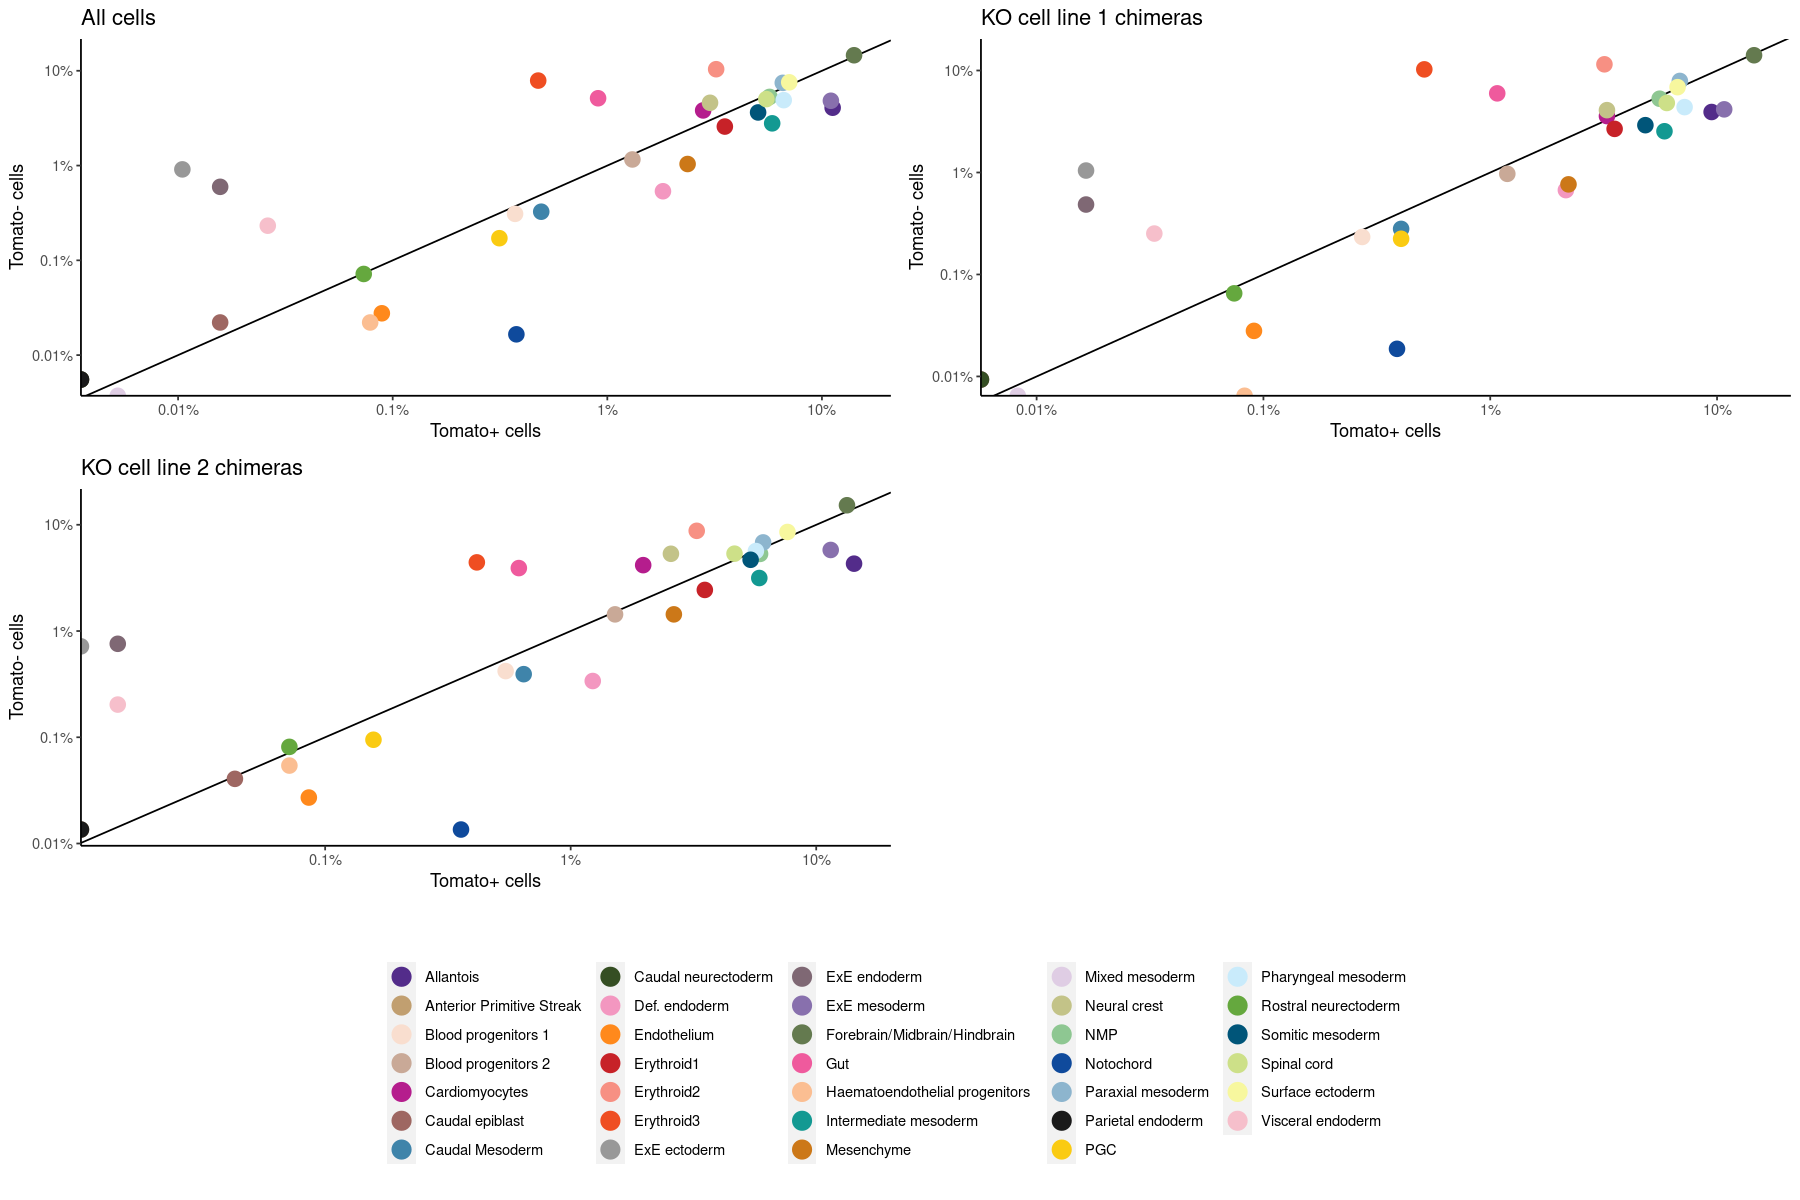

In [13]:

# colors
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")

pdfall = table(meta$celltype.mapped, meta$tdTom)
colnames(pdfall) = c("TomT", "TomF")[match(colnames(pdfall), c("pos", "neg"))]
pdfall = sweep(pdfall, 2, colSums(pdfall), "/")
pdfall = as.data.frame.matrix(pdfall)


plegend = ggplot(data = pdfall, mapping = aes(x = TomT, y = TomF, col = rownames(pdfall))) +
  geom_abline(slope = 1, intercept = 0) +
  geom_point(size = 2) +
  scale_colour_manual(values = c(celltype_colours, "Doublet" = "black", "Stripped" = "black"), name = "") +
  labs(x = "Fraction of Tomato+ cells", y = "Fraction of Tomato- cells") +
  ggtitle("all cells") +
  scale_x_log10() +
  scale_y_log10() +
  guides(col = guide_legend(ncol = 5, override.aes = list(size = 5)))

p1 = ggplot(data = pdfall, mapping = aes(x = TomT, y = TomF, col = rownames(pdfall))) +
  geom_abline(slope = 1, intercept = 0) +
  geom_point(size = 4) +
  scale_colour_manual(values = c(celltype_colours, "Doublet" = "black", "Stripped" = "black"), name = "") +
  labs(x = "Tomato+ cells", y = "Tomato- cells") +
  ggtitle("All cells") +
  theme_classic() +
  scale_x_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  scale_y_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  theme(legend.position = "none")

pdf1 = table(meta$celltype.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
colnames(pdf1) = c("TomT", "TomF")[match(colnames(pdf1), c("pos", "neg"))]
pdf1 = sweep(pdf1, 2, colSums(pdf1), "/")
pdf1 = as.data.frame.matrix(pdf1)

p2 = ggplot(data = pdf1, mapping = aes(x = TomT, y = TomF, col = rownames(pdf1))) +
  geom_abline(slope = 1, intercept = 0) +
  geom_point(size = 4) +
  scale_colour_manual(values = c(celltype_colours, "Doublet" = "black", "Stripped" = "black"), name = "") +
  labs(x = "Tomato+ cells", y = "Tomato- cells") +
  ggtitle("KO cell line 1 chimeras") +
  theme_classic() +
  scale_x_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  scale_y_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  theme(legend.position = "none")



pdf2 = table(meta$celltype.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
colnames(pdf2) = c("TomT", "TomF")[match(colnames(pdf2), c("pos", "neg"))]
pdf2 = sweep(pdf2, 2, colSums(pdf2), "/")
pdf2 = as.data.frame.matrix(pdf2)

p3 = ggplot(data = pdf2, mapping = aes(x = TomT, y = TomF, col = rownames(pdf2))) +
  geom_abline(slope = 1, intercept = 0) +
  geom_point(size = 4) +
  scale_colour_manual(values = c(celltype_colours, "Doublet" = "black", "Stripped" = "black"), name = "") +
  labs(x = "Tomato+ cells", y = "Tomato- cells") +
  ggtitle("KO cell line 2 chimeras") +
  theme_classic() +
  scale_x_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  scale_y_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  theme(legend.position = "none")



p = plot_grid(plot_grid(p1, p2, p3), get_legend(plegend), rel_heights = c(0.75, 0.25), ncol = 1)

#psave = plot_grid(p1 + coord_fixed(xlim = c(0.00003, 0.25), ylim = c(0.00003, 0.25)), 
#                  p2 + coord_fixed(xlim = c(0.00003, 0.25), ylim = c(0.00003, 0.25)), p3 + coord_fixed(xlim = c(0.00003, 0.25), ylim = c(0.00003, 0.25)))
options(repr.plot.width = 15, repr.plot.height = 10)
p

In [14]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
pdf(paste0(plot_folder, "chimaera_celltype_fraction.pdf"), height=8, width=10)
    p
dev.off()

png 
  2

In [7]:
# plot projected cell type on UMAP
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=",")) %>% select(1:3)
big_meta = merge(big_meta, umap, by='cell')
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plot_colours.R") 

Warning message:
“Removed 37040 rows containing missing values (geom_point).”
Warning message:
“Removed 32549 rows containing missing values (geom_point).”
Warning message:
“Removed 32549 rows containing missing values (geom_point).”


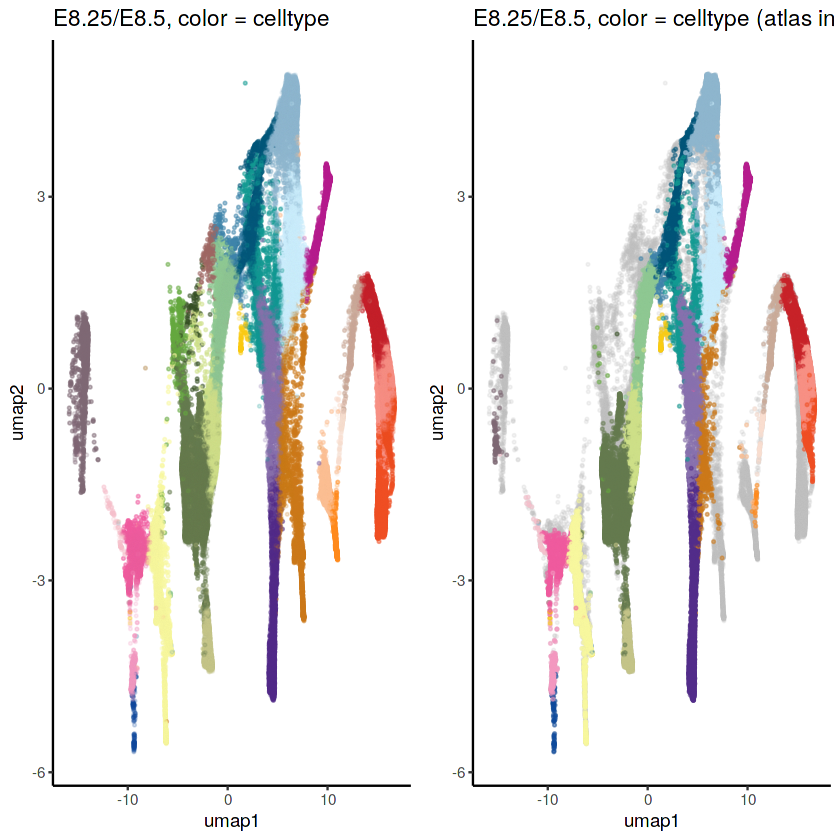

In [8]:
big_meta_85 <- big_meta %>% filter(stage%in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(umap2 >= -10)
p1 <- ggplot(big_meta_85, aes(umap1, umap2, color= celltype)) +
    geom_point(alpha=0.5, size = 0.4) +
    geom_point(data=big_meta_85,aes(color=celltype.mapped),alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    ggtitle('E8.25/E8.5, color = celltype') +
    theme(legend.position = "none")
p2 <- ggplot(big_meta_85, aes(umap1, umap2, color=celltype)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=celltype.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)') +
    theme(legend.position = "none")

plot_grid(p1, p2)

In [184]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_celltype_mapping.png"), height=1000, width=1000)
    grid.arrange(p1, p2)
dev.off()

Warning message:
“Removed 37040 rows containing missing values (geom_point).”
Warning message:
“Removed 32549 rows containing missing values (geom_point).”
Warning message:
“Removed 32549 rows containing missing values (geom_point).”


png 
  2

Warning message:
“Removed 11148 rows containing missing values (geom_point).”
Warning message:
“Removed 11148 rows containing missing values (geom_point).”


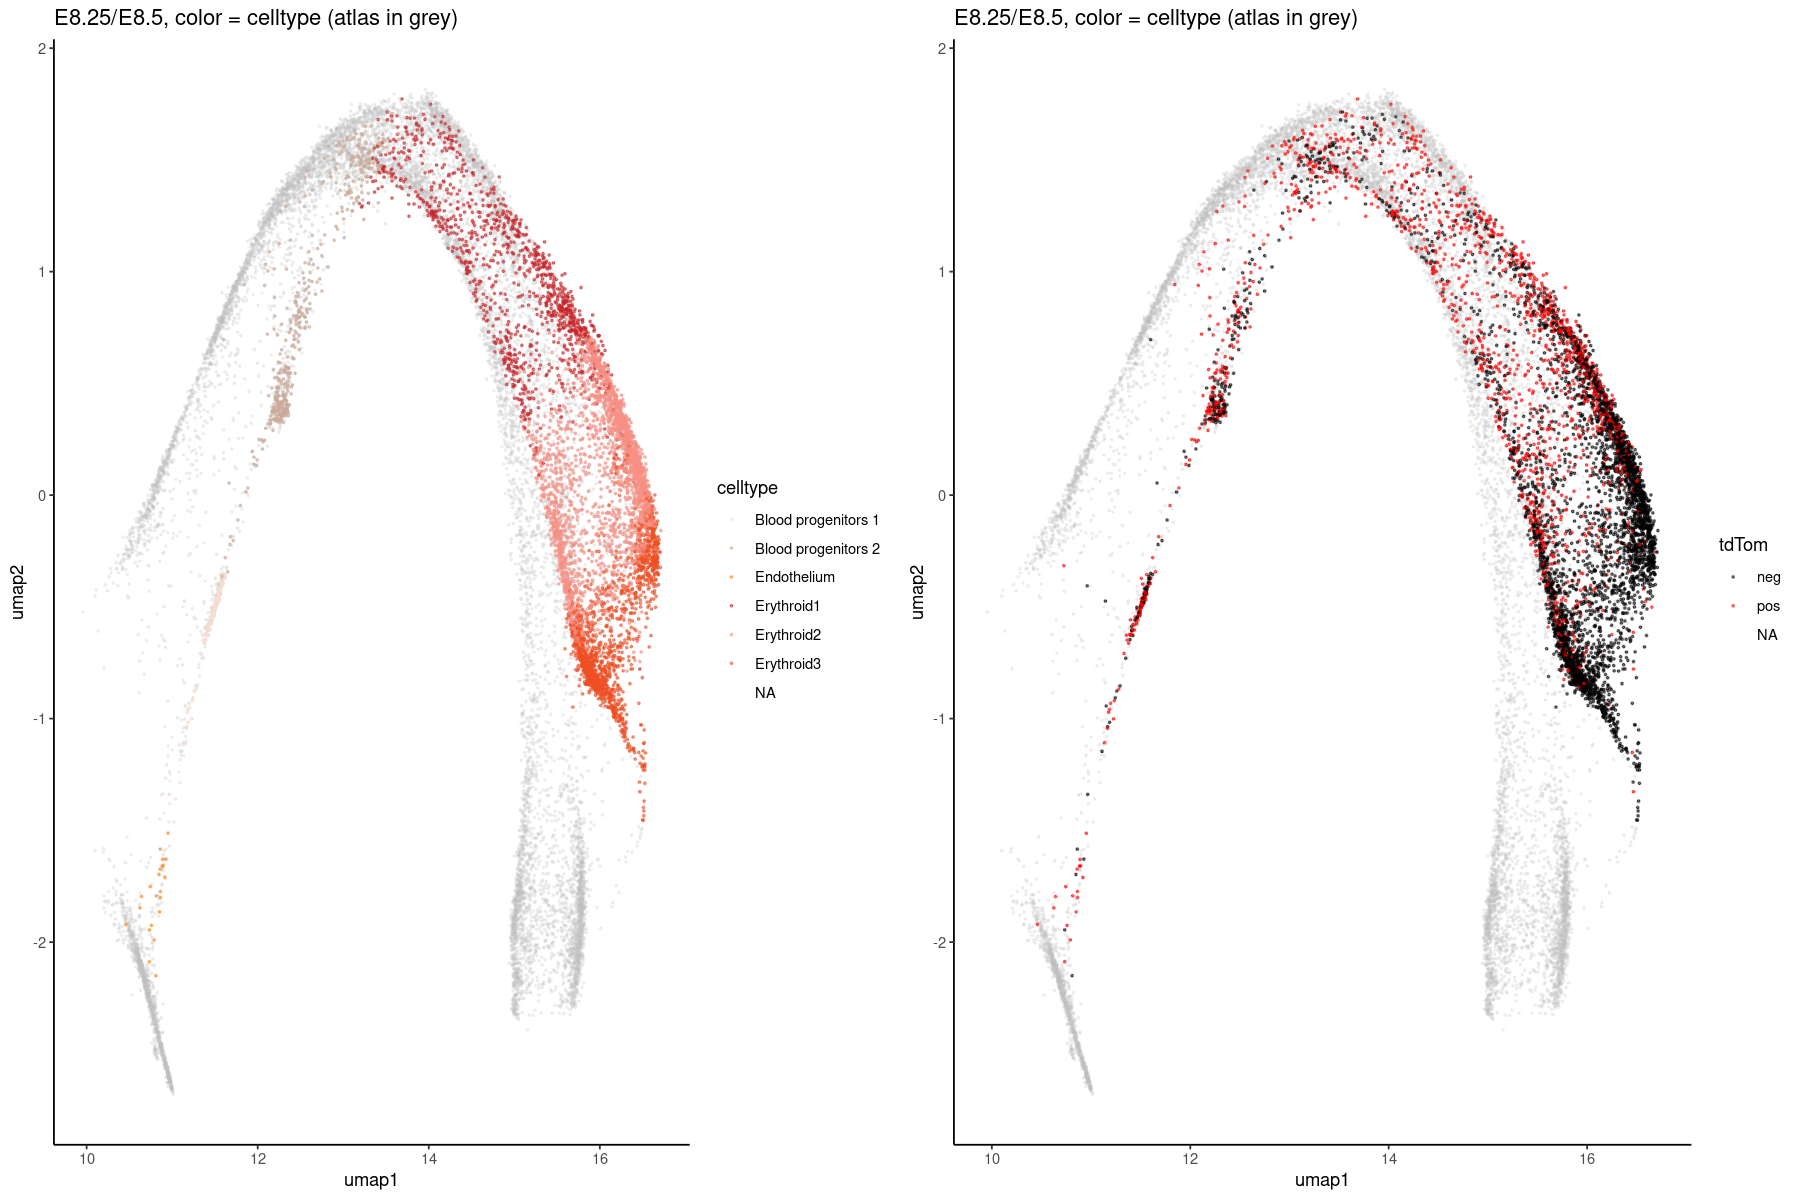

In [16]:
haem <- c( #"Haematoendothelial progenitors",
                     "Endothelium",
                     "Blood progenitors 1",
                     "Blood progenitors 2",
                     "Erythroid1",
                     "Erythroid2",
                     "Erythroid3")
haem_plot <- big_meta %>% filter(celltype %in% haem | celltype.mapped %in% haem)
p1 <- ggplot(haem_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=haem_plot,aes(color=celltype.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)')

p2 <- ggplot(haem_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=haem_plot,aes(color=tdTom),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) + 
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)')
                        
grid.arrange(p1, p2, nrow=1)

In [17]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_haem_mapping.png"), height=750, width=500)
    grid.arrange(p1, p2, nrow = 2)
dev.off()

Warning message:
“Removed 11148 rows containing missing values (geom_point).”
Warning message:
“Removed 11148 rows containing missing values (geom_point).”


png 
  2

In [36]:
head(big_meta)
nrow(big_meta)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gutY,endo_gutDPT,endo_gutCluster,tdTom,weight,stage.mapped,celltype.mapped,closest.cell,umap1,umap2
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<dbl>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,atlas_cell_1,atlas_1,E6.5,AAAGGCCTCCACAA,1,FALSE,FALSE,TS9,0.0431142,2,⋯,NA,NA,NA,NA,1,NA,NA,NA,-6.700929,4.4390874
2,atlas_cell_10,atlas_1,E6.5,AACTGTCTTCGCAA,1,FALSE,FALSE,TS9,0.0000000,1,⋯,NA,NA,NA,NA,10,NA,NA,NA,-6.547600,5.2254179
3,atlas_cell_100,atlas_1,E6.5,CACAGATGGGGACA,1,FALSE,FALSE,TS9,1.2238214,2,⋯,NA,NA,NA,NA,100,NA,NA,NA,-7.397875,5.8998109
4,atlas_cell_1000,atlas_3,E7.5,GCCACTACCCGCTT,1,FALSE,FALSE,TS11,0.7628793,16,⋯,NA,NA,NA,NA,1000,NA,NA,NA,-3.004201,3.4449424
5,atlas_cell_10000,atlas_8,E7.75,GTAGGTACGTGTTG,1,FALSE,FALSE,TS11,0.3390486,1,⋯,NA,NA,NA,NA,10000,NA,NA,NA,-5.643875,2.5210400
6,atlas_cell_100000,atlas_29,E8.5,GACTGATGACACAC,3,FALSE,FALSE,TS12,0.1936071,10,⋯,NA,NA,NA,NA,100000,NA,NA,NA,-3.539111,-0.8655522


[1] 153520

#### Plot on published atlas

In [15]:
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [16]:
head(big_meta)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,tdTom,weight,stage.mapped,celltype.mapped,closest.cell
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,atlas_cell_1,atlas_1,E6.5,AAAGGCCTCCACAA,1,FALSE,FALSE,TS9,0.0431142,2,⋯,NA,NA,NA,NA,NA,NA,1,NA,NA,NA
2,atlas_cell_2,atlas_1,E6.5,AACAAACTCGCCTT,1,FALSE,FALSE,TS9,1.1297133,12,⋯,NA,NA,NA,NA,NA,NA,2,NA,NA,NA
3,atlas_cell_5,atlas_1,E6.5,AACAGAGAATCAGC,1,FALSE,FALSE,TS9,0.1121205,3,⋯,NA,NA,NA,NA,NA,NA,5,NA,NA,NA
4,atlas_cell_6,atlas_1,E6.5,AACATATGAATCGC,1,FALSE,FALSE,TS9,1.2547088,1,⋯,NA,NA,NA,NA,NA,NA,6,NA,NA,NA
5,atlas_cell_8,atlas_1,E6.5,AACCGATGGCTTCC,1,FALSE,FALSE,TS9,1.3457586,2,⋯,NA,NA,NA,NA,NA,NA,8,NA,NA,NA
6,atlas_cell_9,atlas_1,E6.5,AACGTGTGCTCTAT,1,FALSE,FALSE,TS9,1.1463686,2,⋯,NA,NA,NA,NA,NA,NA,9,NA,NA,NA


In [18]:
dim(big_meta)

[1] 153520     33

In [18]:
# Plot based on nearest neighbor?
umap <- big_meta %>% select(cell, umapX, umapY)
colnames(umap) <- c('closest.cell', 'umapX.mapped', 'umapY.mapped')
big_meta <- merge(big_meta, umap, by='closest.cell', all.x=TRUE)

In [19]:
dim(big_meta)

[1] 153520     37

In [20]:
colnames(big_meta)

[1] "closest.cell"        "cell"                "sample"             
 [4] "stage"               "barcode"             "sequencing.batch"   
 [7] "stripped"            "doublet"             "theiler"            
[10] "doub.density"        "cluster"             "cluster.sub"        
[13] "cluster.stage"       "cluster.theiler"     "celltype"           
[16] "colour"              "umapX"               "umapY"              
[19] "haem_gephiX"         "haem_gephiY"         "haem_subclust"      
[22] "endo_gephiX"         "endo_gephiY"         "endo_trajectoryName"
[25] "endo_trajectoryDPT"  "endo_gutX"           "endo_gutY"          
[28] "endo_gutDPT"         "endo_gutCluster"     "weight"             
[31] "stage.mapped"        "celltype.mapped"     "tdTom"              
[34] "umap1"               "umap2"               "umapX.mapped"       
[37] "umapY.mapped"

In [32]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")


p1 <- ggplot(big_meta, aes(umapX, umapY)) + 
    geom_point(color='grey') +
    geom_point(data=big_meta, aes(umapX.mapped, umapY.mapped, color=celltype.mapped), alpha =0.8) +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    theme_classic() +
    theme(text = element_text(size = 20), axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank())
   # theme(legend.position = "none")
          
p2 <- ggplot(big_meta, aes(umapX, umapY)) + 
    geom_point(color='grey') +
    geom_point(data=big_meta, aes(umapX.mapped, umapY.mapped, color=tdTom), alpha =0.5) +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) + 
    theme_classic()+
    theme(text = element_text(size = 20), axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank())

Warning message:
“Removed 37208 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 37208 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”


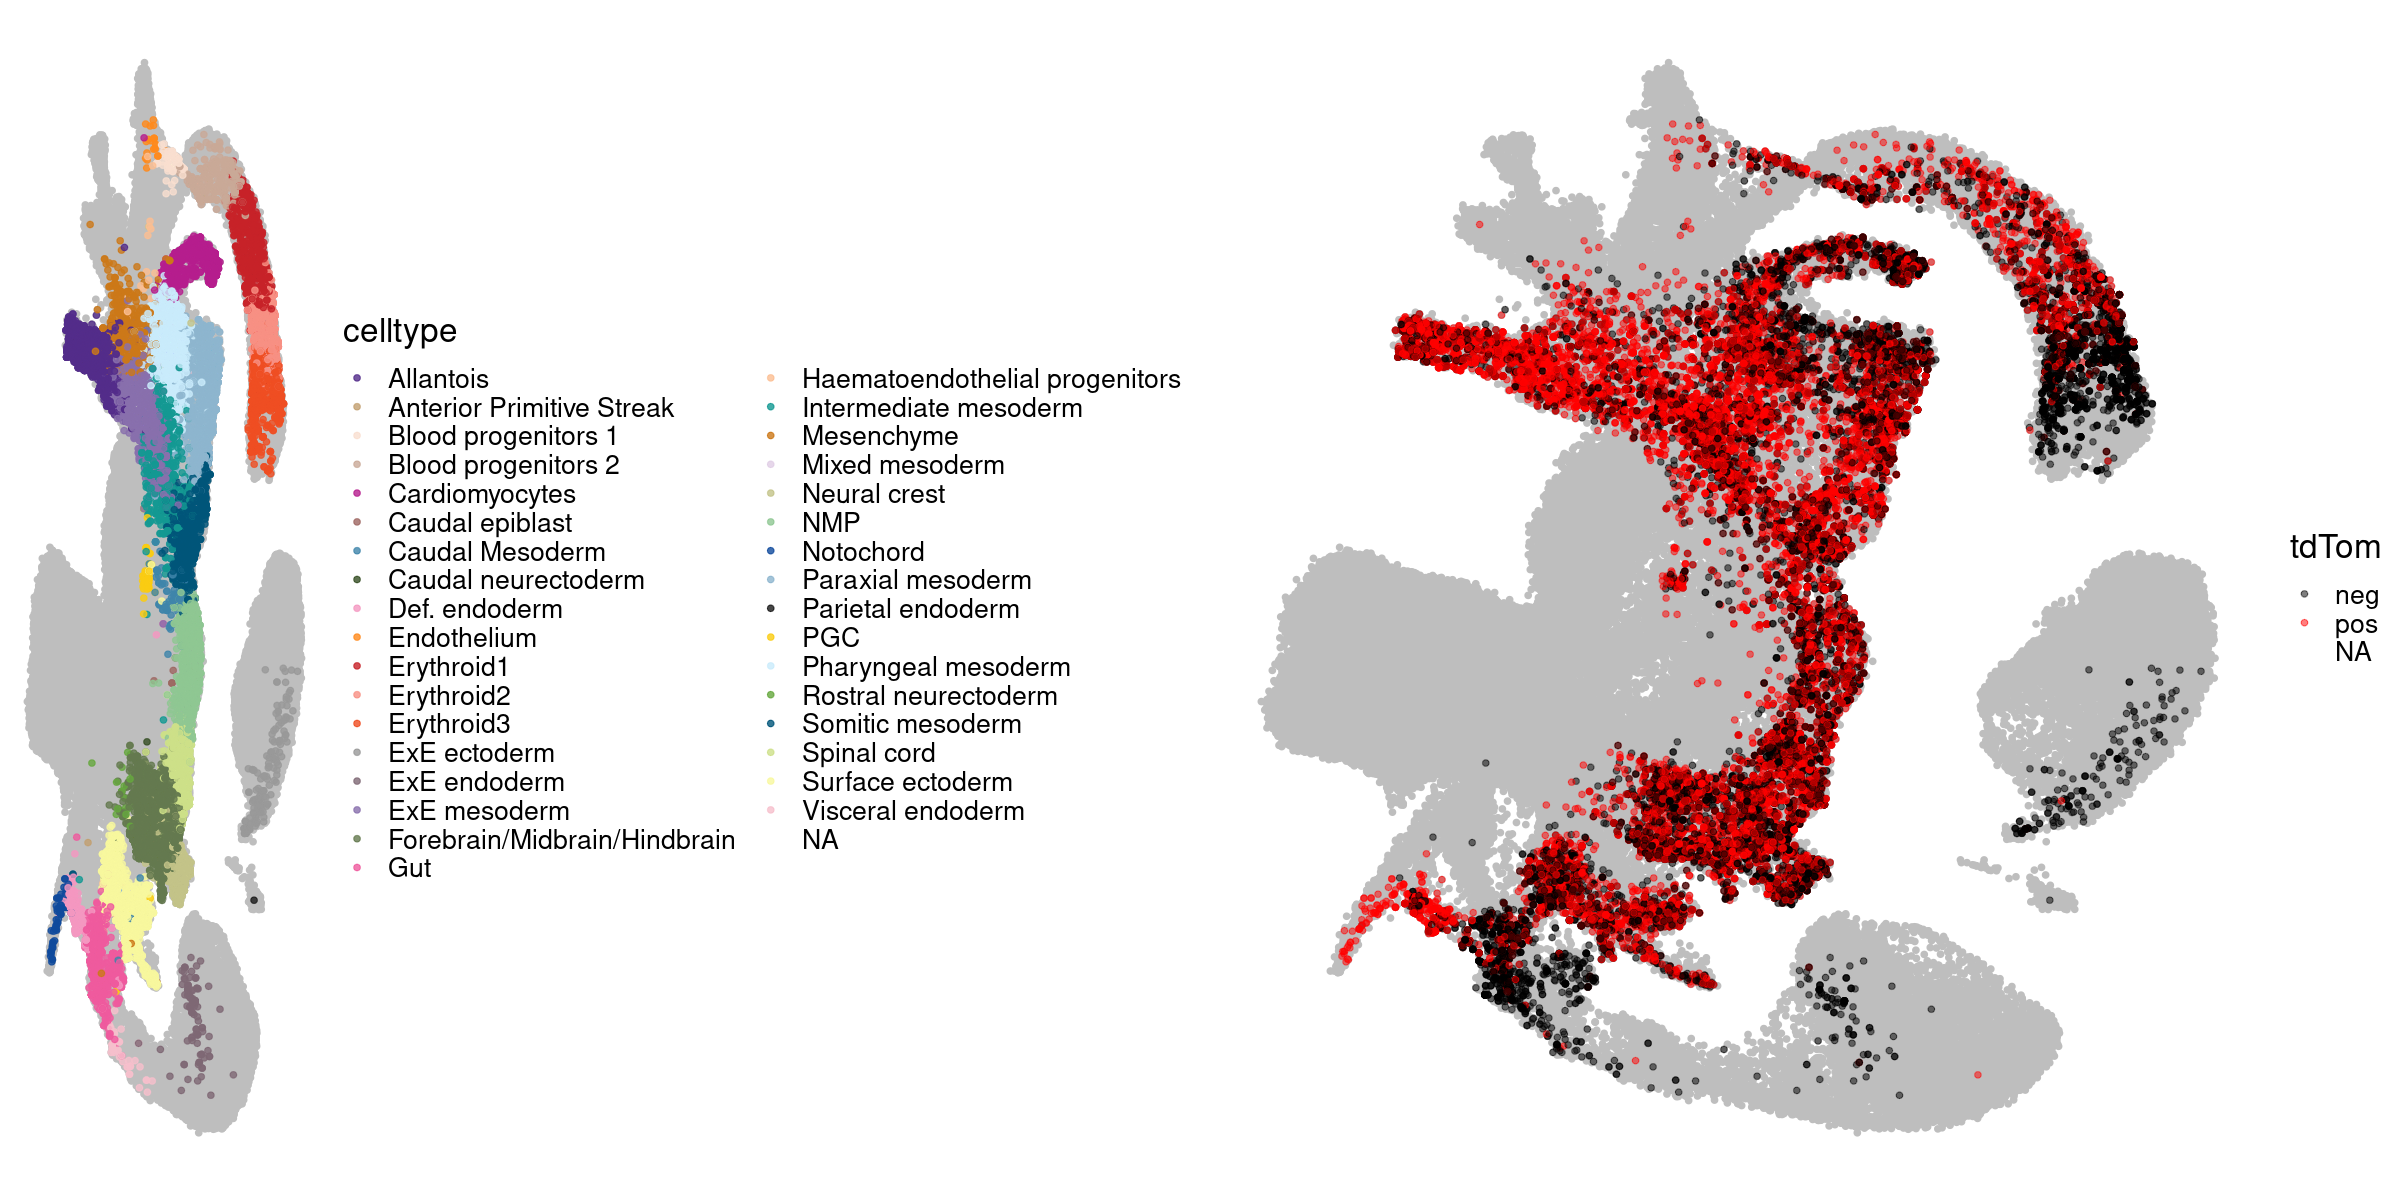

In [33]:
options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, nrow = 1)

In [34]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_projection_publication.png"), height=1000, width=1000)
    grid.arrange(p1, p2, nrow = 2)
dev.off()

Warning message:
“Removed 37208 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 37208 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”


png 
  2

### Timepoint mapping per celltype

Eveluate whether there are celltypes where WT or KO is less progressed than the other to see if KO effects speed at which cells progress through a specific celltype

In [35]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [36]:
meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

In [37]:
unique(meta$celltype.mapped)

[1] "Paraxial mesoderm"              "Erythroid3"                    
 [3] "Pharyngeal mesoderm"            "Forebrain/Midbrain/Hindbrain"  
 [5] "NMP"                            "Erythroid2"                    
 [7] "Surface ectoderm"               "ExE mesoderm"                  
 [9] "Cardiomyocytes"                 "Gut"                           
[11] "Somitic mesoderm"               "Neural crest"                  
[13] "Erythroid1"                     "Spinal cord"                   
[15] "PGC"                            "Intermediate mesoderm"         
[17] "Caudal Mesoderm"                "Blood progenitors 2"           
[19] "ExE endoderm"                   "Allantois"                     
[21] "Blood progenitors 1"            "Def. endoderm"                 
[23] "ExE ectoderm"                   "Mesenchyme"                    
[25] "Notochord"                      "Caudal neurectoderm"           
[27] "Visceral endoderm"              "Endothelium"                   
[29] "Rostral neurectoderm"           "Haematoendothelial progenitors"
[31] "Mixed mesoderm"                 "Caudal epiblast"               
[33] "Parietal endoderm"              "Anterior Primitive Streak"

In [38]:
plot <- list()
celltypes = unique(meta$celltype.mapped)
for(cl in celltypes){
    celltype <- meta %>% filter(celltype.mapped == cl)
    pdf3 = table(celltype$stage.mapped, celltype$tdTom)
    pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

    plot[[cl]] = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
      geom_bar(stat = "identity", position = "dodge") +
      scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                        labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                        name = "") +
      labs(x = "Atlas stage", y = "Fraction of cells") +
      ggtitle(paste0("celltype: ", cl)) +
        theme_classic() + 
        theme(axis.text.x = element_text(angle = -30, hjust = 0),
            legend.position = "none",
            axis.title.x = element_blank()) +
      scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])
}

Warning message:
“CombinePlots is being deprecated. Plots should now be combined using the patchwork system.”


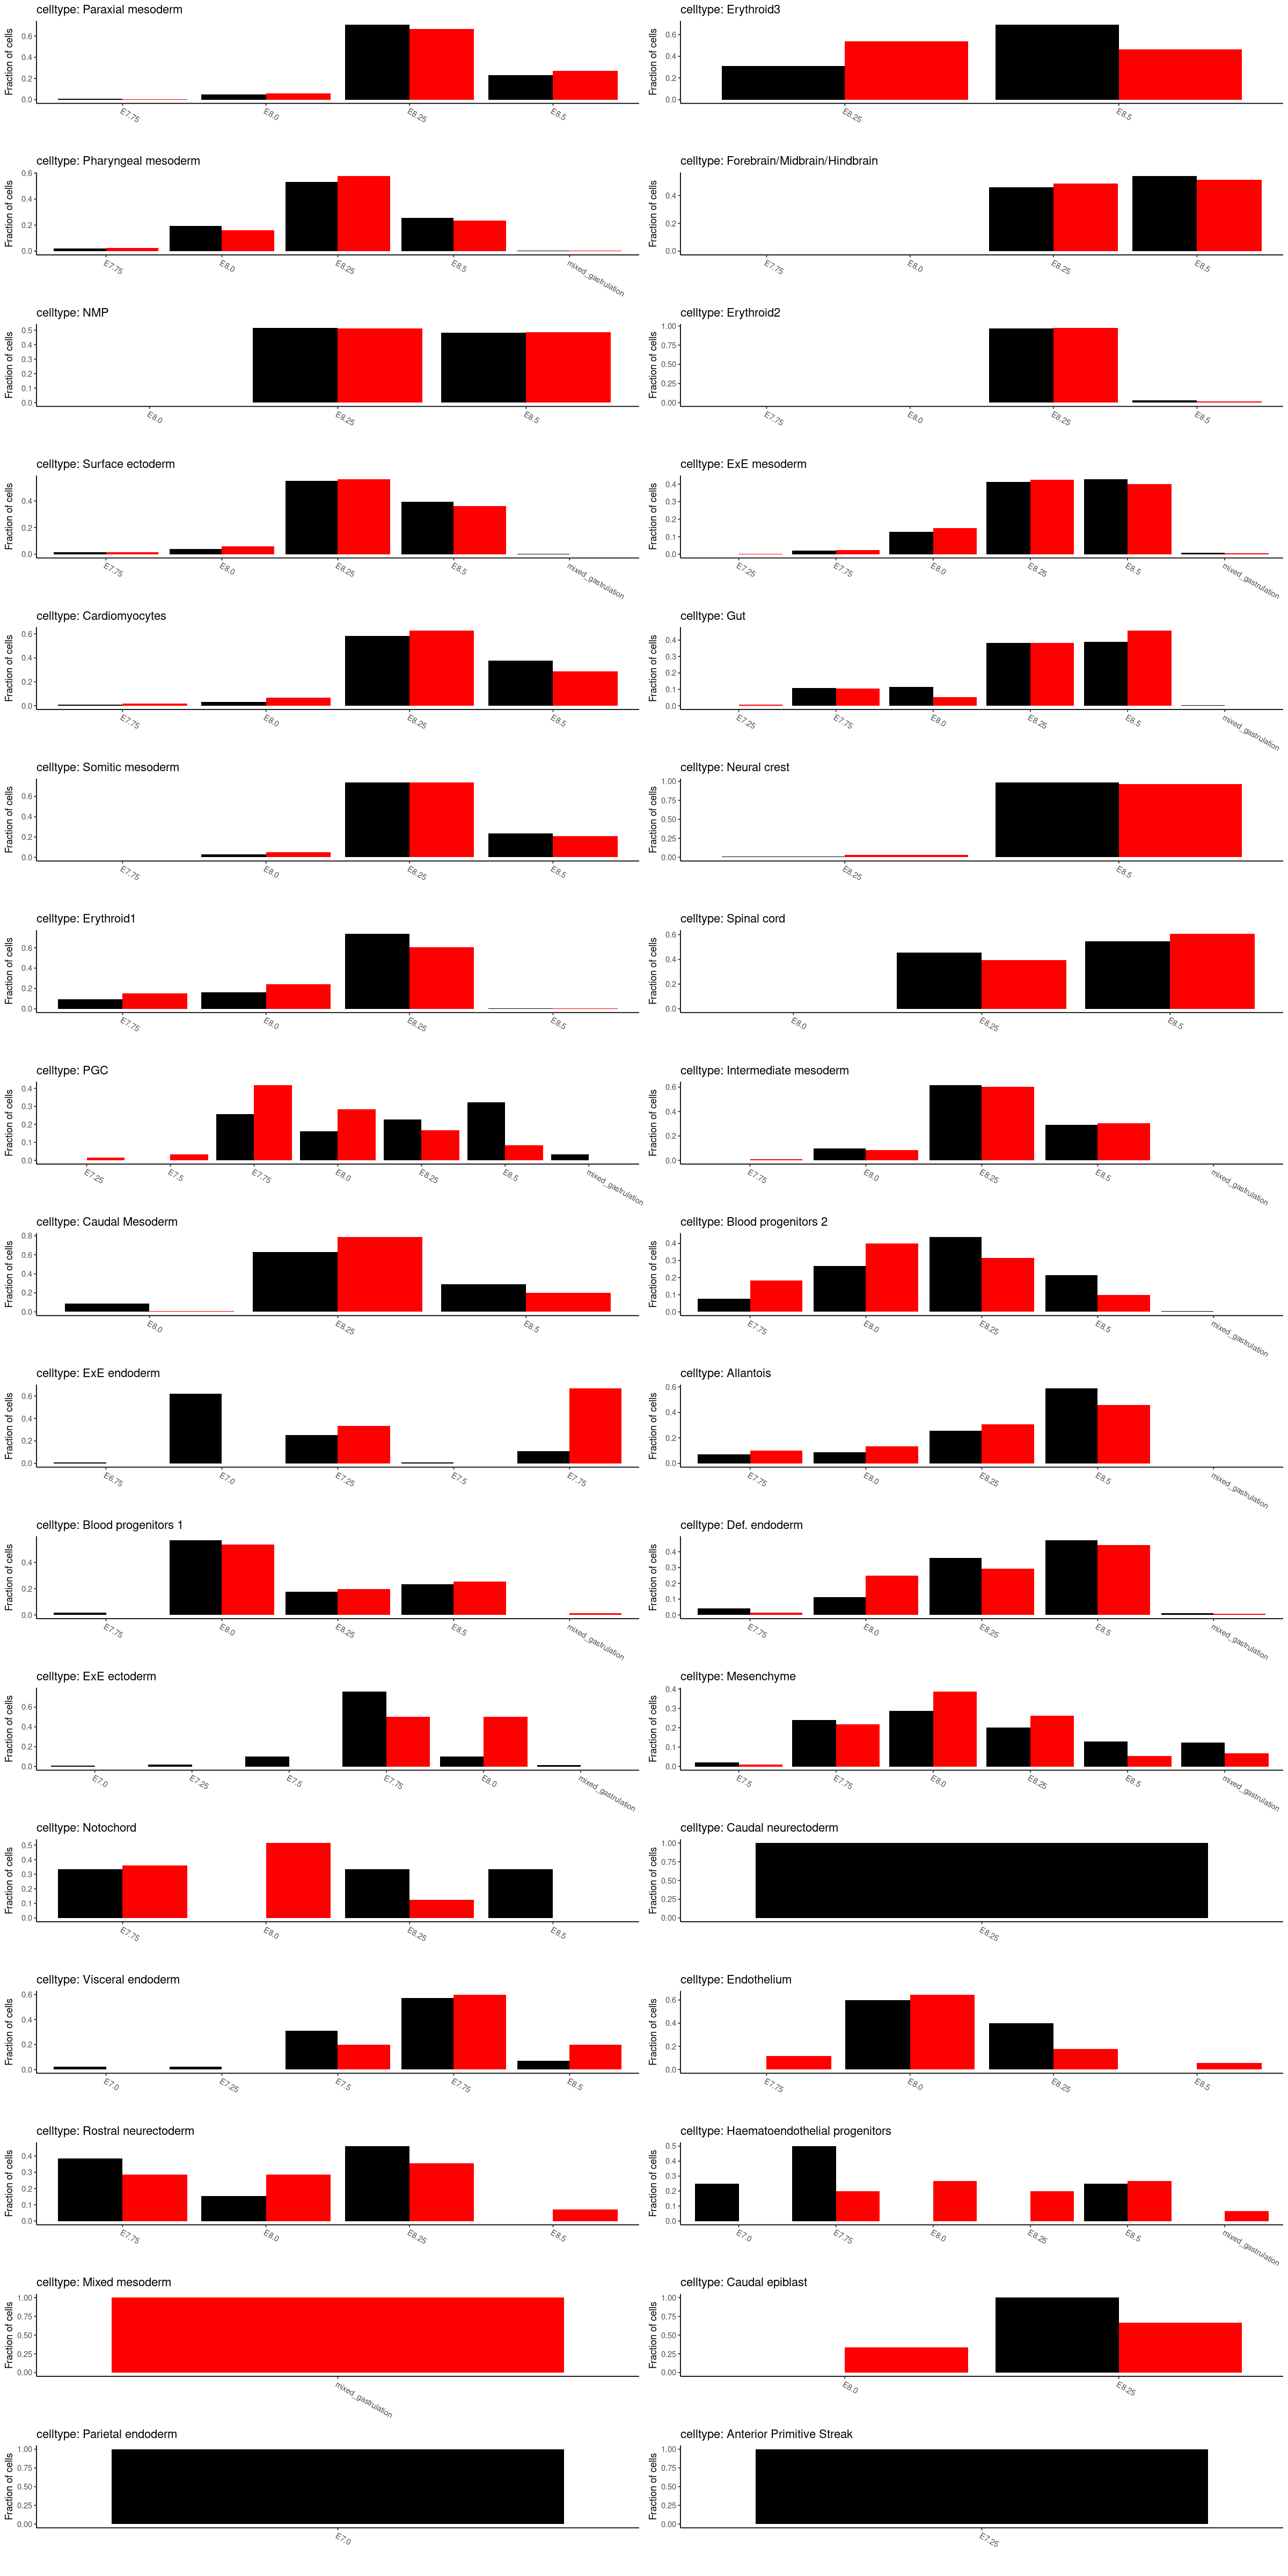

In [39]:
options(repr.plot.width = 20, repr.plot.height = 40)
CombinePlots(plots = plot, ncol = 2, legend = "none")

In [40]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
pdf(paste0(plot_folder, "celltype_timepoint_comparison.pdf"), height=25, width=10)
    CombinePlots(plots = plot, ncol = 4, legend = "none")
dev.off()

Warning message:
“CombinePlots is being deprecated. Plots should now be combined using the patchwork system.”


png 
  2

In [3]:
big_sce <- readRDS(paste0(out_folder, "big_sce_norm.rds"))

In [5]:
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")


In [6]:
head(big_meta)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gephiX,endo_gephiY,endo_trajectoryName,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,tdTom,weight
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>
1,atlas_cell_1,atlas_1,E6.5,AAAGGCCTCCACAA,1,FALSE,FALSE,TS9,0.0431142,2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,1
2,atlas_cell_2,atlas_1,E6.5,AACAAACTCGCCTT,1,FALSE,FALSE,TS9,1.1297133,12,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,2
3,atlas_cell_5,atlas_1,E6.5,AACAGAGAATCAGC,1,FALSE,FALSE,TS9,0.1121205,3,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,5
4,atlas_cell_6,atlas_1,E6.5,AACATATGAATCGC,1,FALSE,FALSE,TS9,1.2547088,1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,6
5,atlas_cell_8,atlas_1,E6.5,AACCGATGGCTTCC,1,FALSE,FALSE,TS9,1.3457586,2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,8
6,atlas_cell_9,atlas_1,E6.5,AACGTGTGCTCTAT,1,FALSE,FALSE,TS9,1.1463686,2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,9
